<a href="https://colab.research.google.com/github/iiiyahiya111/Project/blob/main/Week_4_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **FiLM + JS Disagreement + Conflict-Aware Learned Gate**

WEEK 4 — FiLM + JS DISAGREEMENT + CONFLICT-AWARE GATE
Device: cuda
AMP: True
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Google Drive mounted.

Environment ZIP:
/content/drive/MyDrive/Dataset_1_Image_Environment.zip

Severity ZIP:
/content/drive/MyDrive/Potato_Severity_Dataset_DEDUPED_FINAL.zip

Already extracted: /content/week4_research/datasets/environment

Already extracted: /content/week4_research/datasets/severity

Located files:
Image-level : /content/week4_research/datasets/environment/synthetic_environment_image_level.csv
Daily       : /content/week4_research/datasets/environment/synthetic_environment_daily_v2.csv
Hourly      : /content/week4_research/datasets/environment/synthetic_environment_hourly.csv
Severity    : /content/week4_research/datasets/severity/Potato_Severity_Dataset_FINAL/severity_dataset/potato_severity_FINAL.csv

Dataset shapes:
Environment image-level: (11530, 24)
Environme

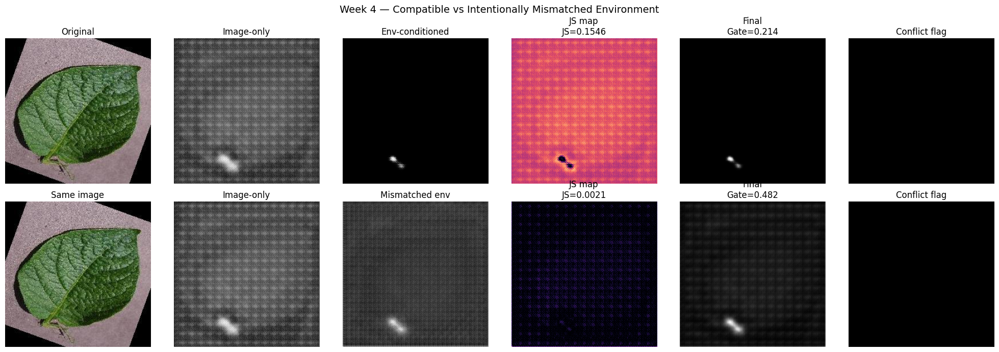


Visualization saved: /content/week4_research/outputs/week4_compatible_vs_mismatched_visualization.png
Compatible filename: 101_Potato_Healthy_train_JPG.rf.140adb40478e116530cc9718b90080a1.jpg
Mismatched environment donor: 197_Potato_Late_Blight_train_JPG.rf.3fe7583ff6a7720bbb4d41a64bd590e5.jpg

WEEK 4 COMPLETE

Best weights: /content/week4_research/outputs/week4_best_state_dict.pt
Best config: /content/week4_research/outputs/week4_best_config.json
Training history: /content/week4_research/outputs/week4_training_history.csv
Mismatch pairs: /content/week4_research/outputs/week4_mismatch_pairs.csv
Visualization: /content/week4_research/outputs/week4_compatible_vs_mismatched_visualization.png

Done.


In [3]:
# =====================================================================
# WEEK 4 RESEARCH VERSION
# FiLM + JS Disagreement + Conflict-Aware Learned Gate
#
# COMPLETE SINGLE-CELL GOOGLE COLAB IMPLEMENTATION
# =====================================================================

# ---------------------------------------------------------------------
# 0. Imports / configuration
# ---------------------------------------------------------------------
import os
import glob
import json
import zipfile
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

from google.colab import drive

warnings.filterwarnings("ignore")

# -------------------------
# Reproducibility
# -------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# -------------------------
# Device / AMP
# -------------------------
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

AMP = DEVICE.type == "cuda"

print("=" * 78)
print("WEEK 4 — FiLM + JS DISAGREEMENT + CONFLICT-AWARE GATE")
print("=" * 78)
print("Device:", DEVICE)
print("AMP:", AMP)


# ---------------------------------------------------------------------
# 1. Mount Google Drive
# ---------------------------------------------------------------------
drive.mount("/content/drive")

print("\nGoogle Drive mounted.")


# ---------------------------------------------------------------------
# 2. Automatically locate ZIP files
# ---------------------------------------------------------------------
ENV_NAME = "Dataset_1_Image_Environment.zip"
SEV_NAME = "Potato_Severity_Dataset_DEDUPED_FINAL.zip"

SEARCH_ROOTS = [
    "/content",
    "/content/drive/MyDrive"
]

def find_file(filename):
    matches = []

    for root in SEARCH_ROOTS:
        matches.extend(
            glob.glob(
                os.path.join(
                    root,
                    "**",
                    filename
                ),
                recursive=True
            )
        )

    # Remove duplicates while preserving order
    matches = list(dict.fromkeys(matches))

    return matches[0] if matches else None


ENV_ZIP = find_file(ENV_NAME)
SEV_ZIP = find_file(SEV_NAME)

if ENV_ZIP is None or SEV_ZIP is None:

    from google.colab import files

    print("\nZIP file(s) not found automatically.")
    print("Upload the missing ZIP file(s).")

    uploaded = files.upload()

    if ENV_ZIP is None and ENV_NAME in uploaded:
        ENV_ZIP = "/content/" + ENV_NAME

    if SEV_ZIP is None and SEV_NAME in uploaded:
        SEV_ZIP = "/content/" + SEV_NAME


if ENV_ZIP is None:
    raise FileNotFoundError(
        f"Could not locate {ENV_NAME}"
    )

if SEV_ZIP is None:
    raise FileNotFoundError(
        f"Could not locate {SEV_NAME}"
    )

print("\nEnvironment ZIP:")
print(ENV_ZIP)

print("\nSeverity ZIP:")
print(SEV_ZIP)


# ---------------------------------------------------------------------
# 3. Extract datasets
# ---------------------------------------------------------------------
ROOT_DIR = "/content/week4_research"

DATA_DIR = os.path.join(
    ROOT_DIR,
    "datasets"
)

ENV_DIR = os.path.join(
    DATA_DIR,
    "environment"
)

SEV_DIR = os.path.join(
    DATA_DIR,
    "severity"
)

OUTPUT_DIR = os.path.join(
    ROOT_DIR,
    "outputs"
)

os.makedirs(
    ENV_DIR,
    exist_ok=True
)

os.makedirs(
    SEV_DIR,
    exist_ok=True
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


def extract_once(zip_path, output_dir):

    marker = os.path.join(
        output_dir,
        ".done"
    )

    if not os.path.exists(marker):

        print("\nExtracting:")
        print(zip_path)

        with zipfile.ZipFile(
            zip_path,
            "r"
        ) as z:

            z.extractall(
                output_dir
            )

        Path(marker).touch()

    else:

        print(
            "\nAlready extracted:",
            output_dir
        )


extract_once(
    ENV_ZIP,
    ENV_DIR
)

extract_once(
    SEV_ZIP,
    SEV_DIR
)


# ---------------------------------------------------------------------
# 4. Locate required CSV files
# ---------------------------------------------------------------------
def find_exact(root, filename):

    matches = glob.glob(
        os.path.join(
            root,
            "**",
            filename
        ),
        recursive=True
    )

    if not matches:
        raise FileNotFoundError(
            f"{filename} not found inside {root}"
        )

    return matches[0]


ENV_IMAGE_CSV = find_exact(
    ENV_DIR,
    "synthetic_environment_image_level.csv"
)

ENV_DAILY_CSV = find_exact(
    ENV_DIR,
    "synthetic_environment_daily_v2.csv"
)

ENV_HOURLY_CSV = find_exact(
    ENV_DIR,
    "synthetic_environment_hourly.csv"
)

SEVERITY_CSV = find_exact(
    SEV_DIR,
    "potato_severity_FINAL.csv"
)

print("\nLocated files:")
print("Image-level :", ENV_IMAGE_CSV)
print("Daily       :", ENV_DAILY_CSV)
print("Hourly      :", ENV_HOURLY_CSV)
print("Severity    :", SEVERITY_CSV)


# ---------------------------------------------------------------------
# 5. Load CSVs
# ---------------------------------------------------------------------
env_image = pd.read_csv(
    ENV_IMAGE_CSV
)

env_daily = pd.read_csv(
    ENV_DAILY_CSV
)

env_hourly = pd.read_csv(
    ENV_HOURLY_CSV
)

severity = pd.read_csv(
    SEVERITY_CSV
)

print("\nDataset shapes:")
print(
    "Environment image-level:",
    env_image.shape
)

print(
    "Environment daily:",
    env_daily.shape
)

print(
    "Environment hourly:",
    env_hourly.shape
)

print(
    "Severity:",
    severity.shape
)


# ---------------------------------------------------------------------
# 6. Keep valid severity records
# ---------------------------------------------------------------------
if "final_decision" in severity.columns:

    severity = severity[
        severity[
            "final_decision"
        ].astype(str).str.upper()
        == "KEEP"
    ].copy()

severity["filename"] = (
    severity["filename"]
    .astype(str)
)

print(
    "\nKept severity samples:",
    len(severity)
)

print(
    severity["split"].value_counts()
)


# ---------------------------------------------------------------------
# 7. Candidate-0 compatible environment
#
# 11530 image-level records correspond to:
#   1153 images × 10 candidates
#
# Candidate 0 is retained as the compatible environment.
#
# All 10 candidates remain available in the environment table,
# but the Week 4 base pairing uses candidate 0 consistently.
# ---------------------------------------------------------------------
env_image_candidate0 = env_image[
    env_image[
        "candidate_id"
    ] == 0
].copy()

env_image_candidate0[
    "filename"
] = env_image_candidate0[
    "filename"
].astype(str)

print(
    "\nCandidate-0 environment records:",
    len(env_image_candidate0)
)


# ---------------------------------------------------------------------
# 8. Construct 144-hour environment sequences
# ---------------------------------------------------------------------
ENV_FEATURES = [
    "temperature",
    "rh",
    "rainfall_hourly_proxy",
    "leaf_wetness_hourly_proxy",
    "soil_moisture",
    "rh_ge90"
]


# -------------------------
# Daily table
# -------------------------
daily = env_daily[
    [
        "filename",
        "image_id",
        "split",
        "class_name",
        "candidate_id",
        "day",
        "rainfall_mm",
        "leaf_wetness_hours",
        "soil_moisture"
    ]
].copy()

daily[
    "rainfall_hourly_proxy"
] = (
    daily["rainfall_mm"] / 24.0
)

daily[
    "leaf_wetness_hourly_proxy"
] = (
    daily["leaf_wetness_hours"] / 24.0
)


# -------------------------
# Hourly table
# -------------------------
hourly = env_hourly[
    [
        "filename",
        "image_id",
        "split",
        "class_name",
        "candidate_id",
        "hour",
        "day",
        "temperature",
        "rh",
        "rh_ge90"
    ]
].copy()


# -------------------------
# Merge daily -> hourly
# -------------------------
hourly = hourly.merge(
    daily[
        [
            "filename",
            "image_id",
            "split",
            "class_name",
            "candidate_id",
            "day",
            "rainfall_hourly_proxy",
            "leaf_wetness_hourly_proxy",
            "soil_moisture"
        ]
    ],
    on=[
        "filename",
        "image_id",
        "split",
        "class_name",
        "candidate_id",
        "day"
    ],
    how="left"
)


# -------------------------
# First 144 hours
# -------------------------
hourly = hourly[
    hourly["hour"] < 144
].copy()


env_sequences_raw = {}

for key, group in hourly.groupby(
    [
        "filename",
        "candidate_id"
    ]
):

    group = group.sort_values(
        "hour"
    )

    if len(group) < 144:
        continue

    seq = group.iloc[
        :144
    ][ENV_FEATURES].values.astype(
        np.float32
    )

    seq = np.nan_to_num(
        seq,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    env_sequences_raw[
        key
    ] = seq


print(
    "\nConstructed 144-hour sequences:",
    len(env_sequences_raw)
)


# ---------------------------------------------------------------------
# 9. Build matched severity records
# ---------------------------------------------------------------------
records = []

for _, row in severity.iterrows():

    filename = row["filename"]

    env_key = (
        filename,
        0
    )

    if env_key not in env_sequences_raw:
        continue

    records.append(
        {
            "filename":
                filename,

            "split":
                str(row["split"]),

            "class_name":
                str(row["class_name"]),

            "severity_percent":
                float(
                    row["severity_percent"]
                ),

            "image_path_original":
                str(row["image_path"]),

            "mask_path_original":
                str(
                    row["lesion_mask_path"]
                ),

            "env_key":
                env_key
        }
    )


dataset_df = pd.DataFrame(
    records
)

print(
    "\nMatched samples:",
    len(dataset_df)
)

print(
    dataset_df["split"].value_counts()
)


# ---------------------------------------------------------------------
# 10. Resolve actual image/mask files
# ---------------------------------------------------------------------
ALL_IMAGE_FILES = {}

for root, dirs, files_ in os.walk(
    SEV_DIR
):

    for file in files_:

        if file.lower().endswith(
            (
                ".jpg",
                ".jpeg",
                ".png"
            )
        ):

            ALL_IMAGE_FILES[
                file
            ] = os.path.join(
                root,
                file
            )


def resolve_file(path_text):

    base = os.path.basename(
        str(path_text)
    )

    return ALL_IMAGE_FILES.get(
        base,
        None
    )


dataset_df[
    "image_path"
] = dataset_df[
    "image_path_original"
].apply(
    resolve_file
)

dataset_df[
    "mask_path"
] = dataset_df[
    "mask_path_original"
].apply(
    resolve_file
)

dataset_df = dataset_df.dropna(
    subset=[
        "image_path",
        "mask_path"
    ]
).reset_index(
    drop=True
)

print(
    "\nSamples with actual image/mask:",
    len(dataset_df)
)


# ---------------------------------------------------------------------
# 11. Train / valid / test
# ---------------------------------------------------------------------
train_df = dataset_df[
    dataset_df["split"] == "train"
].reset_index(drop=True)

valid_df = dataset_df[
    dataset_df["split"] == "valid"
].reset_index(drop=True)

test_df = dataset_df[
    dataset_df["split"] == "test"
].reset_index(drop=True)

print("\nFinal splits:")
print("Train:", len(train_df))
print("Valid:", len(valid_df))
print("Test :", len(test_df))


# ---------------------------------------------------------------------
# 12. Train-only environment normalization
#
# IMPORTANT:
# normalization statistics use only compatible train environments.
# No validation/test statistics enter normalization.
# ---------------------------------------------------------------------
train_env_arrays = []

for key in train_df[
    "env_key"
].tolist():

    train_env_arrays.append(
        env_sequences_raw[
            key
        ]
    )

train_env_concat = np.concatenate(
    train_env_arrays,
    axis=0
)

env_mean = np.mean(
    train_env_concat,
    axis=0
)

env_std = np.std(
    train_env_concat,
    axis=0
)

env_std[
    env_std < 1e-6
] = 1.0


env_sequences = {}

for key, seq in env_sequences_raw.items():

    seq = (
        seq - env_mean
    ) / env_std

    env_sequences[
        key
    ] = seq.astype(
        np.float32
    )


print(
    "\nEnvironment normalization fitted on TRAIN only."
)


# ---------------------------------------------------------------------
# 13. Build hard-negative mismatched environments
#
# Rules:
#   - same train/valid/test split
#   - donor filename != base filename
#   - prefer a different class when available
#   - choose an environment summary that is far away in
#     normalized environment space
#
# This avoids cross-split leakage.
# ---------------------------------------------------------------------
def environment_summary(key):

    seq = env_sequences[
        key
    ]

    # Temporal mean + temporal variability
    mean_part = np.mean(
        seq,
        axis=0
    )

    std_part = np.std(
        seq,
        axis=0
    )

    return np.concatenate(
        [
            mean_part,
            std_part
        ],
        axis=0
    )


summary_cache = {}

for key in env_sequences:

    if key[1] == 0:

        summary_cache[
            key
        ] = environment_summary(
            key
        )


def build_mismatch_map(df):

    rows = df.reset_index(
        drop=True
    ).copy()

    filenames = rows[
        "filename"
    ].tolist()

    classes = rows[
        "class_name"
    ].tolist()

    summaries = np.stack(
        [
            summary_cache[
                (f, 0)
            ]
            for f in filenames
        ]
    )

    mismatch = {}

    for i, filename in enumerate(
        filenames
    ):

        # Same split only because df was already split-specific.
        candidates = [
            j
            for j in range(
                len(filenames)
            )
            if filenames[j] != filename
        ]

        if not candidates:
            raise RuntimeError(
                "No mismatch candidate available."
            )

        # Prefer a different class.
        different_class = [
            j
            for j in candidates
            if classes[j] != classes[i]
        ]

        if len(
            different_class
        ) >= 1:

            pool = different_class

        else:

            pool = candidates

        target = summaries[i]

        pool_vectors = summaries[
            pool
        ]

        dists = np.mean(
            (
                pool_vectors
                - target[None, :]
            ) ** 2,
            axis=1
        )

        best_local = int(
            np.argmax(dists)
        )

        donor_idx = pool[
            best_local
        ]

        donor_filename = filenames[
            donor_idx
        ]

        mismatch[
            filename
        ] = (
            donor_filename,
            float(
                dists[best_local]
            )
        )

    return mismatch


train_mismatch = build_mismatch_map(
    train_df
)

valid_mismatch = build_mismatch_map(
    valid_df
)

test_mismatch = build_mismatch_map(
    test_df
)


def attach_mismatch(df, mismatch_map):

    df = df.copy()

    df["mismatch_filename"] = df[
        "filename"
    ].map(
        lambda x:
        mismatch_map[x][0]
    )

    df["mismatch_key"] = df[
        "mismatch_filename"
    ].map(
        lambda x:
        (x, 0)
    )

    df["mismatch_distance"] = df[
        "filename"
    ].map(
        lambda x:
        mismatch_map[x][1]
    )

    return df


train_df = attach_mismatch(
    train_df,
    train_mismatch
)

valid_df = attach_mismatch(
    valid_df,
    valid_mismatch
)

test_df = attach_mismatch(
    test_df,
    test_mismatch
)


# Save pair mapping for reproducibility.
pair_table = pd.concat(
    [
        train_df[
            [
                "filename",
                "split",
                "mismatch_filename",
                "mismatch_distance"
            ]
        ],
        valid_df[
            [
                "filename",
                "split",
                "mismatch_filename",
                "mismatch_distance"
            ]
        ],
        test_df[
            [
                "filename",
                "split",
                "mismatch_filename",
                "mismatch_distance"
            ]
        ]
    ],
    ignore_index=True
)

pair_table.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "week4_mismatch_pairs.csv"
    ),
    index=False
)


print(
    "\nMismatch maps created:"
)

print(
    "Train:",
    len(train_df)
)

print(
    "Valid:",
    len(valid_df)
)

print(
    "Test :",
    len(test_df)
)


# ---------------------------------------------------------------------
# 14. Dataset transforms
# ---------------------------------------------------------------------
IMG_SIZE = 256

train_transform = A.Compose(
    [
        A.Resize(
            IMG_SIZE,
            IMG_SIZE
        ),

        A.HorizontalFlip(
            p=0.5
        ),

        A.VerticalFlip(
            p=0.2
        ),

        A.RandomRotate90(
            p=0.2
        ),

        A.Normalize(
            mean=(
                0.485,
                0.456,
                0.406
            ),
            std=(
                0.229,
                0.224,
                0.225
            )
        ),

        ToTensorV2()
    ]
)


valid_transform = A.Compose(
    [
        A.Resize(
            IMG_SIZE,
            IMG_SIZE
        ),

        A.Normalize(
            mean=(
                0.485,
                0.456,
                0.406
            ),
            std=(
                0.229,
                0.224,
                0.225
            )
        ),

        ToTensorV2()
    ]
)


# ---------------------------------------------------------------------
# 15. Dataset
# ---------------------------------------------------------------------
class Week4Dataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform
    ):

        self.df = dataframe.reset_index(
            drop=True
        )

        self.transform = transform

    def __len__(self):
        return len(
            self.df
        )

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = np.array(
            Image.open(
                row["image_path"]
            ).convert("RGB")
        )

        mask = np.array(
            Image.open(
                row["mask_path"]
            ).convert("L")
        )

        mask = (
            mask > 0
        ).astype(
            np.float32
        )

        if self.transform is not None:

            transformed = self.transform(
                image=image,
                mask=mask
            )

            image = transformed[
                "image"
            ]

            mask = transformed[
                "mask"
            ]

        if mask.ndim == 2:

            mask = mask.unsqueeze(0)

        env_compatible = torch.tensor(
            env_sequences[
                row["env_key"]
            ],
            dtype=torch.float32
        )

        env_mismatch = torch.tensor(
            env_sequences[
                row["mismatch_key"]
            ],
            dtype=torch.float32
        )

        return {
            "image":
                image,

            "mask":
                mask.float(),

            "environment_compatible":
                env_compatible,

            "environment_mismatch":
                env_mismatch,

            "filename":
                row["filename"],

            "mismatch_filename":
                row["mismatch_filename"],

            "severity":
                torch.tensor(
                    row["severity_percent"],
                    dtype=torch.float32
                )
        }


# ---------------------------------------------------------------------
# 16. DataLoaders
# ---------------------------------------------------------------------
BATCH_SIZE = 8

train_ds = Week4Dataset(
    train_df,
    train_transform
)

valid_ds = Week4Dataset(
    valid_df,
    valid_transform
)

test_ds = Week4Dataset(
    test_df,
    valid_transform
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("\nDataloaders ready.")


# ---------------------------------------------------------------------
# 17. Model components
# ---------------------------------------------------------------------
class ConvBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.block = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                out_channels,
                out_channels,
                3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(
                inplace=True
            )
        )

    def forward(self, x):
        return self.block(x)


class ImageEncoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.b1 = ConvBlock(
            3,
            32
        )

        self.b2 = ConvBlock(
            32,
            64
        )

        self.b3 = ConvBlock(
            64,
            128
        )

        self.b4 = ConvBlock(
            128,
            256
        )

        self.pool = nn.MaxPool2d(
            2
        )

    def forward(self, x):

        x = self.b1(x)
        x = self.pool(x)

        x = self.b2(x)
        x = self.pool(x)

        x = self.b3(x)
        x = self.pool(x)

        x = self.b4(x)
        x = self.pool(x)

        return x


class EnvironmentEncoder(nn.Module):

    def __init__(
        self,
        input_dim=6,
        hidden_dim=128
    ):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.projection = nn.Sequential(

            nn.Linear(
                hidden_dim * 2,
                hidden_dim
            ),

            nn.ReLU(),

            nn.Dropout(
                0.1
            )
        )

    def forward(self, x):

        _, (h, _) = self.lstm(
            x
        )

        forward_h = h[-2]
        backward_h = h[-1]

        h = torch.cat(
            [
                forward_h,
                backward_h
            ],
            dim=1
        )

        return self.projection(
            h
        )


class FiLM(nn.Module):

    def __init__(
        self,
        env_dim,
        channels
    ):

        super().__init__()

        self.gamma = nn.Linear(
            env_dim,
            channels
        )

        self.beta = nn.Linear(
            env_dim,
            channels
        )

    def forward(
        self,
        x,
        env_embedding
    ):

        gamma = self.gamma(
            env_embedding
        ).unsqueeze(
            -1
        ).unsqueeze(
            -1
        )

        beta = self.beta(
            env_embedding
        ).unsqueeze(
            -1
        ).unsqueeze(
            -1
        )

        return (
            gamma * x + beta
        )


class DecoderBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            2,
            stride=2
        )

        self.conv = ConvBlock(
            out_channels,
            out_channels
        )

    def forward(self, x):

        x = self.up(x)

        x = self.conv(
            x
        )

        return x


# ---------------------------------------------------------------------
# 18. Research-valid Week 4 model
# ---------------------------------------------------------------------
class Week4Model(nn.Module):

    def __init__(
        self,
        env_dim=128
    ):

        super().__init__()

        # Image branch
        self.image_encoder = ImageEncoder()

        # Environment branch
        self.environment_encoder = EnvironmentEncoder(
            input_dim=6,
            hidden_dim=env_dim
        )

        # FiLM decoder
        self.dec4 = DecoderBlock(
            256,
            128
        )

        self.dec3 = DecoderBlock(
            128,
            64
        )

        self.dec2 = DecoderBlock(
            64,
            32
        )

        self.dec1 = DecoderBlock(
            32,
            16
        )

        self.film4 = FiLM(
            env_dim,
            128
        )

        self.film3 = FiLM(
            env_dim,
            64
        )

        self.film2 = FiLM(
            env_dim,
            32
        )

        self.film1 = FiLM(
            env_dim,
            16
        )

        # Independent prediction heads
        self.image_head = nn.Conv2d(
            16,
            1,
            1
        )

        self.environment_head = nn.Conv2d(
            16,
            1,
            1
        )

        # Fused prediction
        self.fused_head = nn.Sequential(

            nn.Conv2d(
                32,
                16,
                3,
                padding=1
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                16,
                1,
                1
            )
        )

        # -------------------------------------------------------------
        # LEARNED GATE
        #
        # Inputs:
        #   1. JS disagreement
        #   2. image confidence
        #   3. environment confidence
        #
        # Direct conflict supervision:
        #   compatible = 0
        #   mismatch   = 1
        # -------------------------------------------------------------
        self.gate_mlp = nn.Sequential(

            nn.LayerNorm(3),

            nn.Linear(
                3,
                32
            ),

            nn.ReLU(),

            nn.Linear(
                32,
                16
            ),

            nn.ReLU(),

            nn.Linear(
                16,
                1
            )
        )

    def encode_image(
        self,
        image
    ):

        return self.image_encoder(
            image
        )

    def image_features(
        self,
        z
    ):

        x = self.dec4(z)
        x = self.dec3(x)
        x = self.dec2(x)
        x = self.dec1(x)

        return x

    def environment_features(
        self,
        z,
        env_embedding
    ):

        x = self.dec4(z)

        x = self.film4(
            x,
            env_embedding
        )

        x = self.dec3(x)

        x = self.film3(
            x,
            env_embedding
        )

        x = self.dec2(x)

        x = self.film2(
            x,
            env_embedding
        )

        x = self.dec1(x)

        x = self.film1(
            x,
            env_embedding
        )

        return x

    @staticmethod
    def js_divergence_binary(
        p,
        q
    ):

        # Explicit FP32 for numerical stability.
        p = p.float().clamp(
            1e-6,
            1.0 - 1e-6
        )

        q = q.float().clamp(
            1e-6,
            1.0 - 1e-6
        )

        m = 0.5 * (
            p + q
        )

        kl_pm = (
            p * (
                torch.log(p)
                - torch.log(m)
            )
            +
            (1.0 - p) * (
                torch.log(1.0 - p)
                -
                torch.log(1.0 - m)
            )
        )

        kl_qm = (
            q * (
                torch.log(q)
                - torch.log(m)
            )
            +
            (1.0 - q) * (
                torch.log(1.0 - q)
                -
                torch.log(1.0 - m)
            )
        )

        return 0.5 * (
            kl_pm + kl_qm
        )

    def predict_from_features(
        self,
        z,
        image_feat,
        environment
    ):

        env_embedding = (
            self.environment_encoder(
                environment
            )
        )

        env_feat = (
            self.environment_features(
                z,
                env_embedding
            )
        )

        image_logits = (
            self.image_head(
                image_feat
            )
        )

        environment_logits = (
            self.environment_head(
                env_feat
            )
        )

        fused_features = torch.cat(
            [
                image_feat,
                env_feat
            ],
            dim=1
        )

        fused_logits = (
            self.fused_head(
                fused_features
            )
        )

        # -------------------------------------------------------------
        # Numerically sensitive region explicitly in FP32
        # -------------------------------------------------------------
        image_prob = torch.sigmoid(
            image_logits.float()
        )

        environment_prob = torch.sigmoid(
            environment_logits.float()
        )

        js_map = self.js_divergence_binary(
            image_prob,
            environment_prob
        )

        js_score = js_map.mean(
            dim=(1, 2, 3)
        )

        # Confidence in [0,1]
        image_confidence = (
            2.0
            *
            torch.abs(
                image_prob - 0.5
            )
        ).mean(
            dim=(1, 2, 3)
        )

        environment_confidence = (
            2.0
            *
            torch.abs(
                environment_prob - 0.5
            )
        ).mean(
            dim=(1, 2, 3)
        )

        gate_features = torch.stack(
            [
                js_score,
                image_confidence,
                environment_confidence
            ],
            dim=1
        ).float()

        # Gate MLP deliberately FP32
        gate_logit = self.gate_mlp(
            gate_features
        ).squeeze(1)

        learned_gate = torch.sigmoid(
            gate_logit
        )

        return {
            "image_logits":
                image_logits,

            "environment_logits":
                environment_logits,

            "fused_logits":
                fused_logits,

            "image_prob":
                image_prob,

            "environment_prob":
                environment_prob,

            "js_map":
                js_map,

            "js_score":
                js_score,

            "image_confidence":
                image_confidence,

            "environment_confidence":
                environment_confidence,

            "gate_features":
                gate_features,

            "gate_logit":
                gate_logit,

            "learned_gate":
                learned_gate
        }


model = Week4Model().to(
    DEVICE
)

print(
    "\nModel parameters:",
    sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )
)


# ---------------------------------------------------------------------
# 19. Loss functions
# ---------------------------------------------------------------------
def dice_loss(
    logits,
    targets,
    eps=1e-6
):

    logits = logits.float()
    targets = targets.float()

    probs = torch.sigmoid(
        logits
    )

    intersection = (
        probs * targets
    ).sum(
        dim=(1, 2, 3)
    )

    denominator = (
        probs.sum(
            dim=(1, 2, 3)
        )
        +
        targets.sum(
            dim=(1, 2, 3)
        )
    )

    dice = (
        2.0 * intersection
        + eps
    ) / (
        denominator
        + eps
    )

    return (
        1.0 - dice.mean()
    )


def segmentation_loss(
    logits,
    targets
):

    logits = logits.float()
    targets = targets.float()

    bce = F.binary_cross_entropy_with_logits(
        logits,
        targets
    )

    dice = dice_loss(
        logits,
        targets
    )

    return (
        bce + dice
    )


def conflict_training_loss(
    compatible,
    mismatch
):

    # -------------------------------------------------------------
    # 1. Direct conflict labels
    # -------------------------------------------------------------
    gate_logits = torch.cat(
        [
            compatible[
                "gate_logit"
            ],
            mismatch[
                "gate_logit"
            ]
        ],
        dim=0
    ).float()

    labels = torch.cat(
        [
            torch.zeros_like(
                compatible[
                    "gate_logit"
                ]
            ),
            torch.ones_like(
                mismatch[
                    "gate_logit"
                ]
            )
        ],
        dim=0
    ).float()

    gate_bce = F.binary_cross_entropy_with_logits(
        gate_logits,
        labels
    )

    # -------------------------------------------------------------
    # 2. JS ranking
    #
    # mismatch JS should be larger than compatible JS.
    # -------------------------------------------------------------
    js_c = compatible[
        "js_score"
    ].float()

    js_m = mismatch[
        "js_score"
    ].float()

    margin = 0.03

    js_rank = F.relu(
        margin
        + js_c
        - js_m
    ).mean()

    # -------------------------------------------------------------
    # 3. Pull compatible disagreement downward
    # -------------------------------------------------------------
    compatible_target = 0.02

    js_compatible_pull = F.relu(
        js_c
        - compatible_target
    ).pow(2).mean()

    # -------------------------------------------------------------
    # 4. Push mismatched disagreement upward,
    #    but avoid forcing it toward maximum JS=0.69.
    # -------------------------------------------------------------
    mismatch_target = 0.08
    mismatch_upper = 0.45

    js_mismatch_push = F.relu(
        mismatch_target
        - js_m
    ).pow(2).mean()

    js_mismatch_upper = F.relu(
        js_m
        - mismatch_upper
    ).pow(2).mean()

    total = (
        1.00 * gate_bce
        +
        0.60 * js_rank
        +
        0.10 * js_compatible_pull
        +
        0.10 * js_mismatch_push
        +
        0.03 * js_mismatch_upper
    )

    return {
        "loss":
            total,

        "gate_bce":
            gate_bce,

        "js_rank":
            js_rank,

        "js_compatible":
            js_c.mean(),

        "js_mismatch":
            js_m.mean(),

        "gate_compatible":
            compatible[
                "learned_gate"
            ].mean(),

        "gate_mismatch":
            mismatch[
                "learned_gate"
            ].mean()
    }


# ---------------------------------------------------------------------
# 20. Optimizer + AMP scaler
# ---------------------------------------------------------------------
LR = 1e-4
WEIGHT_DECAY = 1e-4
MAX_GRAD_NORM = 1.0

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

try:

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=AMP
    )

except Exception:

    scaler = torch.cuda.amp.GradScaler(
        enabled=AMP
    )


# ---------------------------------------------------------------------
# 21. One train epoch
# ---------------------------------------------------------------------
def train_one_epoch(
    model,
    loader,
    optimizer,
    scaler
):

    model.train()

    total_losses = []
    fused_losses = []
    env_losses = []
    gate_losses = []
    rank_losses = []

    js_c_values = []
    js_m_values = []

    gate_c_values = []
    gate_m_values = []

    skipped_batches = 0

    for batch_idx, batch in enumerate(
        loader
    ):

        images = batch[
            "image"
        ].to(
            DEVICE,
            non_blocking=True
        )

        masks = batch[
            "mask"
        ].to(
            DEVICE,
            non_blocking=True
        )

        env_c = batch[
            "environment_compatible"
        ].to(
            DEVICE,
            non_blocking=True
        )

        env_m = batch[
            "environment_mismatch"
        ].to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        # ---------------------------------------------------------
        # AMP only around feature/prediction computation.
        # JS + gate/loss are explicitly FP32.
        # ---------------------------------------------------------
        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=AMP
        ):

            z = model.encode_image(
                images
            )

            image_feat = (
                model.image_features(
                    z
                )
            )

            # Same image representation for both environments
            out_c = model.predict_from_features(
                z,
                image_feat,
                env_c
            )

            out_m = model.predict_from_features(
                z,
                image_feat,
                env_m
            )

        # ---------------------------------------------------------
        # Segmentation loss ONLY on compatible environment.
        #
        # Why?
        # A mismatched pair is an intentional counterfactual
        # conflict example, not a valid environment for the lesion.
        # We do not force its environment-conditioned prediction
        # to match the lesion mask.
        # ---------------------------------------------------------
        image_loss = segmentation_loss(
            out_c[
                "image_logits"
            ],
            masks
        )

        env_loss = segmentation_loss(
            out_c[
                "environment_logits"
            ],
            masks
        )

        fused_loss = segmentation_loss(
            out_c[
                "fused_logits"
            ],
            masks
        )

        conflict_losses = conflict_training_loss(
            out_c,
            out_m
        )

        total_loss = (
            0.25 * image_loss
            +
            0.50 * env_loss
            +
            1.00 * fused_loss
            +
            0.75 * conflict_losses[
                "loss"
            ]
        )

        # ---------------------------------------------------------
        # Safety guard
        # ---------------------------------------------------------
        finite = torch.isfinite(
            total_loss
        )

        if not bool(
            finite.item()
        ):

            skipped_batches += 1

            print(
                f"WARNING: skipped non-finite batch "
                f"{batch_idx}"
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            continue

        # ---------------------------------------------------------
        # Backward
        # ---------------------------------------------------------
        scaler.scale(
            total_loss
        ).backward()

        scaler.unscale_(
            optimizer
        )

        grad_norm = torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            MAX_GRAD_NORM,
            error_if_nonfinite=False
        )

        if not torch.isfinite(
            torch.as_tensor(
                grad_norm
            )
        ):

            skipped_batches += 1

            optimizer.zero_grad(
                set_to_none=True
            )

            scaler.update()

            print(
                f"WARNING: non-finite gradients "
                f"at batch {batch_idx}; "
                f"step skipped."
            )

            continue

        scaler.step(
            optimizer
        )

        scaler.update()

        # ---------------------------------------------------------
        # Logging
        # ---------------------------------------------------------
        total_losses.append(
            total_loss.item()
        )

        fused_losses.append(
            fused_loss.item()
        )

        env_losses.append(
            env_loss.item()
        )

        gate_losses.append(
            conflict_losses[
                "gate_bce"
            ].item()
        )

        rank_losses.append(
            conflict_losses[
                "js_rank"
            ].item()
        )

        js_c_values.append(
            conflict_losses[
                "js_compatible"
            ].item()
        )

        js_m_values.append(
            conflict_losses[
                "js_mismatch"
            ].item()
        )

        gate_c_values.append(
            conflict_losses[
                "gate_compatible"
            ].item()
        )

        gate_m_values.append(
            conflict_losses[
                "gate_mismatch"
            ].item()
        )

        if batch_idx % 20 == 0:

            print(
                f"Batch {batch_idx:03d} | "
                f"Total {total_loss.item():.4f} | "
                f"Fused {fused_loss.item():.4f} | "
                f"Env {env_loss.item():.4f} | "
                f"Gate {conflict_losses['gate_bce'].item():.4f} | "
                f"JS-rank {conflict_losses['js_rank'].item():.4f} | "
                f"JS-C {conflict_losses['js_compatible'].item():.4f} | "
                f"JS-M {conflict_losses['js_mismatch'].item():.4f} | "
                f"Gate-C {conflict_losses['gate_compatible'].item():.4f} | "
                f"Gate-M {conflict_losses['gate_mismatch'].item():.4f}"
            )

    def safe_mean(values):

        if not values:
            return float("nan")

        return float(
            np.mean(values)
        )

    return {
        "loss":
            safe_mean(
                total_losses
            ),

        "fused_loss":
            safe_mean(
                fused_losses
            ),

        "env_loss":
            safe_mean(
                env_losses
            ),

        "gate_loss":
            safe_mean(
                gate_losses
            ),

        "rank_loss":
            safe_mean(
                rank_losses
            ),

        "js_c":
            safe_mean(
                js_c_values
            ),

        "js_m":
            safe_mean(
                js_m_values
            ),

        "gate_c":
            safe_mean(
                gate_c_values
            ),

        "gate_m":
            safe_mean(
                gate_m_values
            ),

        "skipped":
            skipped_batches
    }


# ---------------------------------------------------------------------
# 22. Validation
# ---------------------------------------------------------------------
@torch.no_grad()
def collect_pair_outputs(
    model,
    loader
):

    model.eval()

    data = {
        "js_c": [],
        "js_m": [],
        "gate_c": [],
        "gate_m": [],
        "image_conf_c": [],
        "env_conf_c": []
    }

    seg_losses = []

    for batch in loader:

        images = batch[
            "image"
        ].to(
            DEVICE,
            non_blocking=True
        )

        masks = batch[
            "mask"
        ].to(
            DEVICE,
            non_blocking=True
        )

        env_c = batch[
            "environment_compatible"
        ].to(
            DEVICE,
            non_blocking=True
        )

        env_m = batch[
            "environment_mismatch"
        ].to(
            DEVICE,
            non_blocking=True
        )

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=AMP
        ):

            z = model.encode_image(
                images
            )

            image_feat = (
                model.image_features(
                    z
                )
            )

            out_c = model.predict_from_features(
                z,
                image_feat,
                env_c
            )

            out_m = model.predict_from_features(
                z,
                image_feat,
                env_m
            )

        seg_loss = segmentation_loss(
            out_c[
                "fused_logits"
            ],
            masks
        )

        seg_losses.append(
            seg_loss.item()
        )

        data["js_c"].extend(
            out_c[
                "js_score"
            ].cpu().numpy().tolist()
        )

        data["js_m"].extend(
            out_m[
                "js_score"
            ].cpu().numpy().tolist()
        )

        data["gate_c"].extend(
            out_c[
                "learned_gate"
            ].cpu().numpy().tolist()
        )

        data["gate_m"].extend(
            out_m[
                "learned_gate"
            ].cpu().numpy().tolist()
        )

        data["image_conf_c"].extend(
            out_c[
                "image_confidence"
            ].cpu().numpy().tolist()
        )

        data["env_conf_c"].extend(
            out_c[
                "environment_confidence"
            ].cpu().numpy().tolist()
        )

    data["js_c"] = np.asarray(
        data["js_c"],
        dtype=np.float32
    )

    data["js_m"] = np.asarray(
        data["js_m"],
        dtype=np.float32
    )

    data["gate_c"] = np.asarray(
        data["gate_c"],
        dtype=np.float32
    )

    data["gate_m"] = np.asarray(
        data["gate_m"],
        dtype=np.float32
    )

    data["image_conf_c"] = np.asarray(
        data["image_conf_c"],
        dtype=np.float32
    )

    data["env_conf_c"] = np.asarray(
        data["env_conf_c"],
        dtype=np.float32
    )

    data["seg_loss"] = float(
        np.mean(seg_losses)
    )

    return data


# ---------------------------------------------------------------------
# 23. Threshold calibration
# ---------------------------------------------------------------------
def balanced_accuracy(
    scores,
    labels,
    threshold
):

    scores = np.asarray(
        scores
    )

    labels = np.asarray(
        labels
    )

    predictions = (
        scores >= threshold
    ).astype(
        np.int32
    )

    positive = labels == 1
    negative = labels == 0

    if positive.sum() > 0:

        tpr = (
            predictions[
                positive
            ].mean()
        )

    else:

        tpr = 0.0

    if negative.sum() > 0:

        tnr = (
            1.0
            -
            predictions[
                negative
            ].mean()
        )

    else:

        tnr = 0.0

    return 0.5 * (
        tpr + tnr
    )


def calibrate_js_threshold(
    js_c,
    js_m
):

    scores = np.concatenate(
        [
            js_c,
            js_m
        ]
    )

    labels = np.concatenate(
        [
            np.zeros(
                len(js_c)
            ),
            np.ones(
                len(js_m)
            )
        ]
    )

    low = float(
        np.min(scores)
    )

    high = float(
        np.max(scores)
    )

    if high <= low:

        threshold = low

        return (
            threshold,
            0.5
        )

    thresholds = np.linspace(
        low,
        high,
        300
    )

    best_threshold = thresholds[0]
    best_score = -1.0

    for threshold in thresholds:

        score = balanced_accuracy(
            scores,
            labels,
            threshold
        )

        if score > best_score:

            best_score = score
            best_threshold = threshold

    return (
        float(best_threshold),
        float(best_score)
    )


# ---------------------------------------------------------------------
# 24. Full validation statistics
# ---------------------------------------------------------------------
@torch.no_grad()
def validation_statistics(
    model,
    loader
):

    pair = collect_pair_outputs(
        model,
        loader
    )

    threshold, ba = (
        calibrate_js_threshold(
            pair["js_c"],
            pair["js_m"]
        )
    )

    stats = {
        "seg_loss":
            pair["seg_loss"],

        "threshold":
            threshold,

        "js_balanced_accuracy":
            ba,

        "js_c_mean":
            float(
                pair["js_c"].mean()
            ),

        "js_m_mean":
            float(
                pair["js_m"].mean()
            ),

        "gate_c_mean":
            float(
                pair["gate_c"].mean()
            ),

        "gate_m_mean":
            float(
                pair["gate_m"].mean()
            ),

        "gate_c_flag_percent":
            float(
                100.0
                *
                np.mean(
                    pair["gate_c"]
                    >= 0.5
                )
            ),

        "gate_m_flag_percent":
            float(
                100.0
                *
                np.mean(
                    pair["gate_m"]
                    >= 0.5
                )
            )
    }

    return (
        stats,
        pair
    )


# ---------------------------------------------------------------------
# 25. Training configuration
# ---------------------------------------------------------------------
EPOCHS = 10

best_score = float(
    "inf"
)

BEST_WEIGHTS_PATH = os.path.join(
    OUTPUT_DIR,
    "week4_best_state_dict.pt"
)

BEST_CONFIG_PATH = os.path.join(
    OUTPUT_DIR,
    "week4_best_config.json"
)

history = []

print("\n" + "=" * 78)
print("FULL TRAINING")
print("=" * 78)


# ---------------------------------------------------------------------
# 26. Training loop
# ---------------------------------------------------------------------
for epoch in range(
    1,
    EPOCHS + 1
):

    print("\n" + "-" * 78)
    print(
        f"EPOCH {epoch}/{EPOCHS}"
    )
    print("-" * 78)

    train_stats = train_one_epoch(
        model,
        train_loader,
        optimizer,
        scaler
    )

    val_stats, _ = validation_statistics(
        model,
        valid_loader
    )

    # Combined validation criterion.
    #
    # Segmentation remains the main objective, while gate loss
    # and disagreement calibration contribute a smaller amount.
    validation_score = (
        val_stats["seg_loss"]
        +
        0.25
        *
        (
            1.0
            -
            val_stats[
                "js_balanced_accuracy"
            ]
        )
    )

    print(
        "\nEpoch summary:"
    )

    print(
        "Train loss:",
        train_stats["loss"]
    )

    print(
        "Valid segmentation loss:",
        val_stats["seg_loss"]
    )

    print(
        "Calibrated JS threshold:",
        val_stats["threshold"]
    )

    print(
        "Validation JS balanced accuracy:",
        val_stats[
            "js_balanced_accuracy"
        ]
    )

    print(
        "Compatible mean JS:",
        val_stats[
            "js_c_mean"
        ]
    )

    print(
        "Mismatched mean JS:",
        val_stats[
            "js_m_mean"
        ]
    )

    print(
        "Compatible learned gate:",
        val_stats[
            "gate_c_mean"
        ]
    )

    print(
        "Mismatched learned gate:",
        val_stats[
            "gate_m_mean"
        ]
    )

    print(
        "Compatible conflict rate (%):",
        val_stats[
            "gate_c_flag_percent"
        ]
    )

    print(
        "Mismatched conflict rate (%):",
        val_stats[
            "gate_m_flag_percent"
        ]
    )

    print(
        "Skipped non-finite batches:",
        train_stats[
            "skipped"
        ]
    )

    history.append(
        {
            "epoch": epoch,
            "train_loss": train_stats["loss"],
            "val_seg_loss": val_stats["seg_loss"],
            "js_threshold": val_stats["threshold"],
            "js_ba": val_stats["js_balanced_accuracy"],
            "js_c": val_stats["js_c_mean"],
            "js_m": val_stats["js_m_mean"],
            "gate_c": val_stats["gate_c_mean"],
            "gate_m": val_stats["gate_m_mean"],
            "conflict_c_pct": val_stats["gate_c_flag_percent"],
            "conflict_m_pct": val_stats["gate_m_flag_percent"],
            "skipped": train_stats["skipped"]
        }
    )

    if np.isfinite(
        validation_score
    ) and validation_score < best_score:

        best_score = validation_score

        # IMPORTANT:
        # save ONLY state_dict, not a Python/NumPy-containing
        # arbitrary dictionary.
        torch.save(
            model.state_dict(),
            BEST_WEIGHTS_PATH
        )

        config = {
            "image_size":
                IMG_SIZE,

            "environment_features":
                ENV_FEATURES,

            "js_threshold":
                val_stats["threshold"],

            "validation_score":
                validation_score,

            "epoch":
                epoch
        }

        with open(
            BEST_CONFIG_PATH,
            "w"
        ) as f:

            json.dump(
                config,
                f,
                indent=2
            )

        print(
            "✓ Best model updated."
        )

    else:

        print(
            "No best-model update."
        )


# ---------------------------------------------------------------------
# 27. Save training history
# ---------------------------------------------------------------------
history_df = pd.DataFrame(
    history
)

history_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "week4_training_history.csv"
    ),
    index=False
)


# ---------------------------------------------------------------------
# 28. Load best model safely
#
# state_dict-only checkpoint:
# torch.load(..., weights_only=True)
# ---------------------------------------------------------------------
print("\n" + "=" * 78)
print("LOADING BEST MODEL")
print("=" * 78)

if not os.path.exists(
    BEST_WEIGHTS_PATH
):

    raise FileNotFoundError(
        "Best model checkpoint was not created. "
        "Check training for non-finite losses."
    )

state_dict = torch.load(
    BEST_WEIGHTS_PATH,
    map_location=DEVICE,
    weights_only=True
)

model.load_state_dict(
    state_dict
)

model.to(
    DEVICE
)

model.eval()

with open(
    BEST_CONFIG_PATH,
    "r"
) as f:

    best_config = json.load(
        f
    )

JS_THRESHOLD = float(
    best_config[
        "js_threshold"
    ]
)

print(
    "Best epoch:",
    best_config[
        "epoch"
    ]
)

print(
    "Best JS threshold:",
    JS_THRESHOLD
)


# ---------------------------------------------------------------------
# 29. Artificial unit tests
# ---------------------------------------------------------------------
print("\n" + "=" * 78)
print("UNIT TESTS — ARTIFICIAL CONFLICT")
print("=" * 78)

B = 4
H = 32
W = 32


# -------------------------
# Test 1: identical
# -------------------------
test_p = torch.full(
    (
        B,
        1,
        H,
        W
    ),
    0.5,
    device=DEVICE
)

test_q = test_p.clone()

js_identical = model.js_divergence_binary(
    test_p,
    test_q
)

js_identical_score = js_identical.mean(
    dim=(1, 2, 3)
)

js_gate_identical = torch.sigmoid(
    35.0
    *
    (
        js_identical_score
        - JS_THRESHOLD
    )
)

print(
    "\nTest 1 — identical"
)

print(
    "Mean JS:",
    js_identical_score.mean().item()
)

print(
    "Mean JS gate:",
    js_gate_identical.mean().item()
)

assert (
    js_identical_score.mean().item()
    < 1e-6
)

assert (
    js_gate_identical.mean().item()
    < 0.5
)

print(
    "PASS"
)


# -------------------------
# Test 2: strong conflict
# -------------------------
test_p = torch.ones(
    (
        B,
        1,
        H,
        W
    ),
    device=DEVICE
)

test_q = torch.zeros(
    (
        B,
        1,
        H,
        W
    ),
    device=DEVICE
)

js_strong = model.js_divergence_binary(
    test_p,
    test_q
)

js_strong_score = js_strong.mean(
    dim=(1, 2, 3)
)

js_gate_strong = torch.sigmoid(
    35.0
    *
    (
        js_strong_score
        - JS_THRESHOLD
    )
)

print(
    "\nTest 2 — strong conflict"
)

print(
    "Mean JS:",
    js_strong_score.mean().item()
)

print(
    "Mean JS gate:",
    js_gate_strong.mean().item()
)

assert (
    js_strong_score.mean().item()
    > js_identical_score.mean().item()
)

assert (
    js_gate_strong.mean().item()
    > 0.5
)

print(
    "PASS"
)


# -------------------------
# Test 3: partial conflict
# -------------------------
p = torch.full(
    (
        B,
        1,
        H,
        W
    ),
    0.5,
    device=DEVICE
)

q = p.clone()

p[:, :, :, W//2:] = 0.999
q[:, :, :, W//2:] = 0.001

js_partial = model.js_divergence_binary(
    p,
    q
)

agreement_region = js_partial[
    :, :, :, :W//2
].mean()

conflict_region = js_partial[
    :, :, :, W//2:
].mean()

print(
    "\nTest 3 — partial conflict"
)

print(
    "Agreement region:",
    agreement_region.item()
)

print(
    "Conflict region:",
    conflict_region.item()
)

assert (
    conflict_region
    > agreement_region
)

print(
    "PASS"
)


# ---------------------------------------------------------------------
# 30. Real compatible vs mismatched test
# ---------------------------------------------------------------------
print("\n" + "=" * 78)
print("REAL DATA — COMPATIBLE vs MISMATCHED")
print("=" * 78)

val_stats, val_pair = validation_statistics(
    model,
    valid_loader
)

print(
    "\nValidation compatible mean JS:",
    val_stats[
        "js_c_mean"
    ]
)

print(
    "Validation mismatched mean JS:",
    val_stats[
        "js_m_mean"
    ]
)

print(
    "Validation compatible mean learned gate:",
    val_stats[
        "gate_c_mean"
    ]
)

print(
    "Validation mismatched mean learned gate:",
    val_stats[
        "gate_m_mean"
    ]
)

print(
    "Validation compatible conflict rate:",
    val_stats[
        "gate_c_flag_percent"
    ],
    "%"
)

print(
    "Validation mismatched conflict rate:",
    val_stats[
        "gate_m_flag_percent"
    ],
    "%"
)


if (
    val_stats["js_m_mean"]
    >
    val_stats["js_c_mean"]
):

    print(
        "PASS — mismatched JS is higher than compatible JS."
    )

else:

    print(
        "WARNING — JS separation is not yet established."
    )


if (
    val_stats["gate_m_mean"]
    >
    val_stats["gate_c_mean"]
):

    print(
        "PASS — learned gate is higher for mismatched pairs."
    )

else:

    print(
        "WARNING — learned gate separation is not yet established."
    )


# ---------------------------------------------------------------------
# 31. Test-set segmentation + gate evaluation
# ---------------------------------------------------------------------
@torch.no_grad()
def evaluate_test(
    model,
    loader,
    js_threshold
):

    model.eval()

    dice_sum = 0.0
    iou_sum = 0.0

    count = 0

    js_c = []
    js_m = []

    gate_c = []
    gate_m = []

    for batch in loader:

        images = batch[
            "image"
        ].to(
            DEVICE,
            non_blocking=True
        )

        masks = batch[
            "mask"
        ].to(
            DEVICE,
            non_blocking=True
        )

        env_c = batch[
            "environment_compatible"
        ].to(
            DEVICE,
            non_blocking=True
        )

        env_m = batch[
            "environment_mismatch"
        ].to(
            DEVICE,
            non_blocking=True
        )

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=AMP
        ):

            z = model.encode_image(
                images
            )

            image_feat = (
                model.image_features(
                    z
                )
            )

            out_c = model.predict_from_features(
                z,
                image_feat,
                env_c
            )

            out_m = model.predict_from_features(
                z,
                image_feat,
                env_m
            )

        # -------------------------------------------------------------
        # Learned routing:
        #
        # low conflict  -> fused
        # high conflict -> image-only fallback
        #
        # This makes the conflict handling interpretable without
        # introducing an arbitrary "conflict segmentation head".
        # -------------------------------------------------------------
        learned_gate = (
            out_c[
                "learned_gate"
            ]
            .float()
        )

        gate_map = learned_gate.view(
            -1,
            1,
            1,
            1
        )

        final_logits = (
            (
                1.0
                -
                gate_map
            )
            *
            out_c[
                "fused_logits"
            ].float()
            +
            gate_map
            *
            out_c[
                "image_logits"
            ].float()
        )

        prediction = (
            torch.sigmoid(
                final_logits
            )
            >= 0.5
        ).float()

        target = (
            masks
            > 0.5
        ).float()

        intersection = (
            prediction * target
        ).sum(
            dim=(1, 2, 3)
        )

        pred_area = prediction.sum(
            dim=(1, 2, 3)
        )

        target_area = target.sum(
            dim=(1, 2, 3)
        )

        dice = (
            2.0 * intersection + 1e-6
        ) / (
            pred_area
            + target_area
            + 1e-6
        )

        union = (
            pred_area
            +
            target_area
            -
            intersection
        )

        iou = (
            intersection + 1e-6
        ) / (
            union + 1e-6
        )

        dice_sum += dice.sum().item()
        iou_sum += iou.sum().item()

        count += images.shape[0]

        js_c.extend(
            out_c[
                "js_score"
            ].cpu().numpy().tolist()
        )

        js_m.extend(
            out_m[
                "js_score"
            ].cpu().numpy().tolist()
        )

        gate_c.extend(
            learned_gate.cpu().numpy().tolist()
        )

        gate_m.extend(
            out_m[
                "learned_gate"
            ].cpu().numpy().tolist()
        )

    js_c = np.asarray(
        js_c
    )

    js_m = np.asarray(
        js_m
    )

    gate_c = np.asarray(
        gate_c
    )

    gate_m = np.asarray(
        gate_m
    )

    result = {
        "dice":
            dice_sum / max(
                count,
                1
            ),

        "iou":
            iou_sum / max(
                count,
                1
            ),

        "mean_js_compatible":
            float(
                js_c.mean()
            ),

        "mean_js_mismatched":
            float(
                js_m.mean()
            ),

        "mean_gate_compatible":
            float(
                gate_c.mean()
            ),

        "mean_gate_mismatched":
            float(
                gate_m.mean()
            ),

        "compatible_conflict_percent":
            float(
                100.0
                *
                np.mean(
                    gate_c >= 0.5
                )
            ),

        "mismatched_conflict_percent":
            float(
                100.0
                *
                np.mean(
                    gate_m >= 0.5
                )
            ),

        "js_gate_compatible_percent":
            float(
                100.0
                *
                np.mean(
                    js_c >= js_threshold
                )
            ),

        "js_gate_mismatched_percent":
            float(
                100.0
                *
                np.mean(
                    js_m >= js_threshold
                )
            )
    }

    return result


test_results = evaluate_test(
    model,
    test_loader,
    JS_THRESHOLD
)

print(
    "\n" + "=" * 78
)

print(
    "TEST SET RESULTS"
)

print(
    "=" * 78
)

print(
    "Segmentation Dice:",
    test_results[
        "dice"
    ]
)

print(
    "Segmentation IoU:",
    test_results[
        "iou"
    ]
)

print(
    "Mean JS — compatible:",
    test_results[
        "mean_js_compatible"
    ]
)

print(
    "Mean JS — mismatched:",
    test_results[
        "mean_js_mismatched"
    ]
)

print(
    "Mean learned gate — compatible:",
    test_results[
        "mean_gate_compatible"
    ]
)

print(
    "Mean learned gate — mismatched:",
    test_results[
        "mean_gate_mismatched"
    ]
)

print(
    "Conflict flagged — compatible:",
    test_results[
        "compatible_conflict_percent"
    ],
    "%"
)

print(
    "Conflict flagged — mismatched:",
    test_results[
        "mismatched_conflict_percent"
    ],
    "%"
)

print(
    "JS-threshold flagged — compatible:",
    test_results[
        "js_gate_compatible_percent"
    ],
    "%"
)

print(
    "JS-threshold flagged — mismatched:",
    test_results[
        "js_gate_mismatched_percent"
    ],
    "%"
)


# ---------------------------------------------------------------------
# 32. Visualization
#
# Same image:
#   Row 1 = compatible environment
#   Row 2 = mismatched environment
#
# Columns:
#   original image
#   image-only prediction
#   environment-conditioned prediction
#   JS disagreement map
#   final prediction
#   conflict flag
# ---------------------------------------------------------------------
@torch.no_grad()
def visualize_pair(
    model,
    dataset,
    index=0,
    js_threshold=None
):

    model.eval()

    sample = dataset[
        index
    ]

    image = sample[
        "image"
    ].unsqueeze(
        0
    ).to(
        DEVICE
    )

    env_c = sample[
        "environment_compatible"
    ].unsqueeze(
        0
    ).to(
        DEVICE
    )

    env_m = sample[
        "environment_mismatch"
    ].unsqueeze(
        0
    ).to(
        DEVICE
    )

    with torch.autocast(
        device_type="cuda",
        dtype=torch.float16,
        enabled=AMP
    ):

        z = model.encode_image(
            image
        )

        image_feat = (
            model.image_features(
                z
            )
        )

        out_c = model.predict_from_features(
            z,
            image_feat,
            env_c
        )

        out_m = model.predict_from_features(
            z,
            image_feat,
            env_m
        )

    # Original image in display scale.
    display = (
        image[0]
        .detach()
        .cpu()
        .permute(
            1,
            2,
            0
        )
        .numpy()
    )

    mean = np.array(
        [
            0.485,
            0.456,
            0.406
        ]
    )

    std = np.array(
        [
            0.229,
            0.224,
            0.225
        ]
    )

    display = (
        display * std + mean
    )

    display = np.clip(
        display,
        0,
        1
    )

    image_pred = torch.sigmoid(
        out_c[
            "image_logits"
        ].float()
    )[0, 0].cpu().numpy()

    env_pred_c = torch.sigmoid(
        out_c[
            "environment_logits"
        ].float()
    )[0, 0].cpu().numpy()

    env_pred_m = torch.sigmoid(
        out_m[
            "environment_logits"
        ].float()
    )[0, 0].cpu().numpy()

    js_c = out_c[
        "js_map"
    ][0, 0].cpu().numpy()

    js_m = out_m[
        "js_map"
    ][0, 0].cpu().numpy()

    # Learned gate
    gate_c = float(
        out_c[
            "learned_gate"
        ].item()
    )

    gate_m = float(
        out_m[
            "learned_gate"
        ].item()
    )

    # Final compatible prediction
    gate_c_map = torch.tensor(
        gate_c,
        device=DEVICE
    ).view(
        1,
        1,
        1,
        1
    )

    final_c = (
        (
            1.0
            -
            gate_c_map
        )
        *
        out_c[
            "fused_logits"
        ].float()
        +
        gate_c_map
        *
        out_c[
            "image_logits"
        ].float()
    )

    final_c = torch.sigmoid(
        final_c
    )[0, 0].cpu().numpy()

    # Final mismatch prediction
    gate_m_map = torch.tensor(
        gate_m,
        device=DEVICE
    ).view(
        1,
        1,
        1,
        1
    )

    final_m = (
        (
            1.0
            -
            gate_m_map
        )
        *
        out_m[
            "fused_logits"
        ].float()
        +
        gate_m_map
        *
        out_m[
            "image_logits"
        ].float()
    )

    final_m = torch.sigmoid(
        final_m
    )[0, 0].cpu().numpy()

    flag_c = (
        gate_c >= 0.5
    )

    flag_m = (
        gate_m >= 0.5
    )

    fig, axes = plt.subplots(
        2,
        6,
        figsize=(
            20,
            7
        )
    )

    # Row 1: compatible
    axes[0, 0].imshow(
        display
    )

    axes[0, 0].set_title(
        "Original"
    )

    axes[0, 1].imshow(
        image_pred,
        cmap="gray"
    )

    axes[0, 1].set_title(
        "Image-only"
    )

    axes[0, 2].imshow(
        env_pred_c,
        cmap="gray"
    )

    axes[0, 2].set_title(
        "Env-conditioned"
    )

    axes[0, 3].imshow(
        js_c,
        cmap="magma"
    )

    axes[0, 3].set_title(
        f"JS map\nJS={js_c.mean():.4f}"
    )

    axes[0, 4].imshow(
        final_c,
        cmap="gray"
    )

    axes[0, 4].set_title(
        f"Final\nGate={gate_c:.3f}"
    )

    axes[0, 5].imshow(
        np.ones_like(
            js_c
        )
        *
        flag_c,
        cmap="gray"
    )

    axes[0, 5].set_title(
        "Conflict flag"
    )

    # Row 2: mismatch
    axes[1, 0].imshow(
        display
    )

    axes[1, 0].set_title(
        "Same image"
    )

    axes[1, 1].imshow(
        image_pred,
        cmap="gray"
    )

    axes[1, 1].set_title(
        "Image-only"
    )

    axes[1, 2].imshow(
        env_pred_m,
        cmap="gray"
    )

    axes[1, 2].set_title(
        "Mismatched env"
    )

    axes[1, 3].imshow(
        js_m,
        cmap="magma"
    )

    axes[1, 3].set_title(
        f"JS map\nJS={js_m.mean():.4f}"
    )

    axes[1, 4].imshow(
        final_m,
        cmap="gray"
    )

    axes[1, 4].set_title(
        f"Final\nGate={gate_m:.3f}"
    )

    axes[1, 5].imshow(
        np.ones_like(
            js_m
        )
        *
        flag_m,
        cmap="gray"
    )

    axes[1, 5].set_title(
        "Conflict flag"
    )

    for ax in axes.flat:
        ax.axis("off")

    fig.suptitle(
        "Week 4 — Compatible vs Intentionally Mismatched Environment",
        fontsize=14
    )

    plt.tight_layout()

    save_path = os.path.join(
        OUTPUT_DIR,
        "week4_compatible_vs_mismatched_visualization.png"
    )

    plt.savefig(
        save_path,
        dpi=180,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "\nVisualization saved:",
        save_path
    )

    print(
        "Compatible filename:",
        sample[
            "filename"
        ]
    )

    print(
        "Mismatched environment donor:",
        sample[
            "mismatch_filename"
        ]
    )


# Pick a validation example.
visualize_pair(
    model,
    valid_ds,
    index=0,
    js_threshold=JS_THRESHOLD
)


# ---------------------------------------------------------------------
# 33. Final save
# ---------------------------------------------------------------------
results_path = os.path.join(
    OUTPUT_DIR,
    "week4_test_results.json"
)

with open(
    results_path,
    "w"
) as f:

    json.dump(
        test_results,
        f,
        indent=2
    )

print("\n" + "=" * 78)
print("WEEK 4 COMPLETE")
print("=" * 78)

print(
    "\nBest weights:",
    BEST_WEIGHTS_PATH
)

print(
    "Best config:",
    BEST_CONFIG_PATH
)

print(
    "Training history:",
    os.path.join(
        OUTPUT_DIR,
        "week4_training_history.csv"
    )
)

print(
    "Mismatch pairs:",
    os.path.join(
        OUTPUT_DIR,
        "week4_mismatch_pairs.csv"
    )
)

print(
    "Visualization:",
    os.path.join(
        OUTPUT_DIR,
        "week4_compatible_vs_mismatched_visualization.png"
    ))

print(
    "\nDone."
)

# **Diagnosis**

In [4]:
# =====================================================================
# WEEK 4 — NEXT STAGE
# Risk-aware mismatch + Environment sensitivity + Robust JS gate
#
# RUN THIS AFTER THE PREVIOUS WEEK 4 CELL
# =====================================================================

import os
import json
import random
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from torch.utils.data import DataLoader

# ---------------------------------------------------------------------
# 0. Configuration
# ---------------------------------------------------------------------
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

OUTPUT_DIR = "/content/week4_research/outputs"

CURRENT_BEST = os.path.join(
    OUTPUT_DIR,
    "week4_best_state_dict.pt"
)

RISK_BEST = os.path.join(
    OUTPUT_DIR,
    "week4_riskaware_best_state_dict.pt"
)

RISK_CONFIG = os.path.join(
    OUTPUT_DIR,
    "week4_riskaware_config.json"
)

# Fine-tune from the existing best model.
RUN_FINETUNE = True

FINETUNE_EPOCHS = 5
FINETUNE_LR = 2e-5
MAX_GRAD_NORM = 1.0

BATCH_SIZE_RISK = 8

# Gate steepness.
# This is used only after validation threshold calibration.
JS_GATE_K = 35.0

# Training weights.
L_SEG_ENV = 0.50
L_SEG_FUSED = 0.50
L_GATE = 1.00
L_JS_RANK = 1.00
L_JS_COMPAT_PULL = 0.20
L_ENV_SENSITIVITY = 0.40
L_JS_MISMATCH_PUSH = 0.20

JS_MARGIN = 0.03
COMPAT_JS_TARGET = 0.05
MISMATCH_JS_TARGET = 0.08
ENV_SENSITIVITY_MARGIN = 0.03

print("=" * 78)
print("WEEK 4 — RISK-AWARE ENVIRONMENT SENSITIVITY")
print("=" * 78)
print("Device:", DEVICE)
print("Fine-tuning:", RUN_FINETUNE)


# ---------------------------------------------------------------------
# 1. Load current best model
# ---------------------------------------------------------------------
if not os.path.exists(CURRENT_BEST):
    raise FileNotFoundError(
        f"Current best checkpoint not found:\n{CURRENT_BEST}"
    )

state_dict = torch.load(
    CURRENT_BEST,
    map_location=DEVICE,
    weights_only=True
)

model.load_state_dict(
    state_dict
)

model = model.to(DEVICE)
model.eval()

print(
    "\nLoaded current best checkpoint:"
)
print(CURRENT_BEST)


# ---------------------------------------------------------------------
# 2. Build environmental moisture-risk proxy
#
# IMPORTANT:
# This is a COUNTERFACTUAL MATCHING PROXY, not a disease-risk model.
#
# It uses:
#   - fraction of RH>=90 hours
#   - total leaf-wetness proxy
#   - total rainfall proxy
#
# The purpose is to select environments that are strongly different
# from the original environment while preserving train/valid/test split.
# ---------------------------------------------------------------------

assert "env_sequences_raw" in globals(), (
    "env_sequences_raw is missing. "
    "Run the previous Week 4 cell first."
)

assert "train_df" in globals()
assert "valid_df" in globals()
assert "test_df" in globals()


# Candidate-0 only.
base_env_keys = [
    key
    for key in env_sequences_raw.keys()
    if key[1] == 0
]

risk_rows = []

for key in base_env_keys:

    filename, candidate_id = key

    seq = env_sequences_raw[key]

    # Environmental features:
    # 0 = temperature
    # 1 = rh
    # 2 = rainfall_hourly_proxy
    # 3 = leaf_wetness_hourly_proxy
    # 4 = soil_moisture
    # 5 = rh_ge90

    rh90_fraction = float(
        np.mean(seq[:, 5])
    )

    rainfall_total = float(
        np.sum(seq[:, 2])
    )

    wetness_total = float(
        np.sum(seq[:, 3])
    )

    temperature_mean = float(
        np.mean(seq[:, 0])
    )

    rh_mean = float(
        np.mean(seq[:, 1])
    )

    risk_rows.append(
        {
            "filename": filename,
            "rh90_fraction": rh90_fraction,
            "rainfall_total": rainfall_total,
            "wetness_total": wetness_total,
            "temperature_mean": temperature_mean,
            "rh_mean": rh_mean
        }
    )


risk_df = pd.DataFrame(
    risk_rows
)


# ---------------------------------------------------------------------
# Percentile/rank normalization.
# This avoids hard-coded biological thresholds.
# ---------------------------------------------------------------------
def percentile_rank(series):

    values = np.asarray(
        series,
        dtype=np.float64
    )

    order = np.argsort(
        np.argsort(values)
    )

    if len(values) <= 1:
        return np.zeros_like(
            values,
            dtype=np.float64
        )

    return (
        order /
        (len(values) - 1)
    )


risk_df["rh90_rank"] = percentile_rank(
    risk_df["rh90_fraction"]
)

risk_df["rain_rank"] = percentile_rank(
    risk_df["rainfall_total"]
)

risk_df["wetness_rank"] = percentile_rank(
    risk_df["wetness_total"]
)


# Environmental moisture-risk proxy.
risk_df["moisture_risk"] = (
    0.50 * risk_df["rh90_rank"]
    +
    0.30 * risk_df["wetness_rank"]
    +
    0.20 * risk_df["rain_rank"]
)


risk_lookup = dict(
    zip(
        risk_df["filename"],
        risk_df["moisture_risk"]
    )
)


print("\nEnvironmental proxy statistics:")
print(
    risk_df[
        [
            "moisture_risk",
            "rh90_fraction",
            "rainfall_total",
            "wetness_total"
        ]
    ].describe()
)


# ---------------------------------------------------------------------
# 3. Risk-aware mismatch mapping
#
# Same split only.
#
# For each image:
#   choose a different image from the same split
#   preferably from a different class
#   with maximum difference in environmental risk proxy.
#
# This creates a counterfactual environment without moving an image
# between train/validation/test.
# ---------------------------------------------------------------------
def build_risk_mismatch_map(
    df
):

    local = df.reset_index(
        drop=True
    ).copy()

    filenames = local[
        "filename"
    ].tolist()

    classes = local[
        "class_name"
    ].tolist()

    risk_values = np.array(
        [
            risk_lookup[
                f
            ]
            for f in filenames
        ],
        dtype=np.float32
    )

    mismatch_map = {}

    for i, filename in enumerate(
        filenames
    ):

        candidates = [
            j
            for j in range(
                len(filenames)
            )
            if filenames[j] != filename
        ]

        if len(candidates) == 0:
            raise RuntimeError(
                "No mismatch candidate available."
            )

        # Prefer a different disease class when possible.
        different_class = [
            j
            for j in candidates
            if classes[j] != classes[i]
        ]

        if len(different_class) > 0:
            candidate_pool = different_class
        else:
            candidate_pool = candidates

        target_risk = risk_values[i]

        distances = np.array(
            [
                abs(
                    risk_values[j]
                    -
                    target_risk
                )
                for j in candidate_pool
            ]
        )

        donor_local_idx = int(
            np.argmax(distances)
        )

        donor_idx = candidate_pool[
            donor_local_idx
        ]

        donor_filename = filenames[
            donor_idx
        ]

        mismatch_map[
            filename
        ] = {
            "donor_filename":
                donor_filename,

            "risk_distance":
                float(
                    distances[
                        donor_local_idx
                    ]
                ),

            "source_risk":
                float(
                    target_risk
                ),

            "donor_risk":
                float(
                    risk_values[
                        donor_idx
                    ]
                )
        }

    return mismatch_map


train_risk_map = build_risk_mismatch_map(
    train_df
)

valid_risk_map = build_risk_mismatch_map(
    valid_df
)

test_risk_map = build_risk_mismatch_map(
    test_df
)


def attach_risk_mismatch(
    df,
    mismatch_map
):

    out = df.copy()

    out[
        "mismatch_filename"
    ] = out[
        "filename"
    ].map(
        lambda x:
        mismatch_map[x][
            "donor_filename"
        ]
    )

    out[
        "mismatch_key"
    ] = out[
        "mismatch_filename"
    ].map(
        lambda x:
        (x, 0)
    )

    out[
        "mismatch_risk_distance"
    ] = out[
        "filename"
    ].map(
        lambda x:
        mismatch_map[x][
            "risk_distance"
        ]
    )

    out[
        "source_risk"
    ] = out[
        "filename"
    ].map(
        lambda x:
        mismatch_map[x][
            "source_risk"
        ]
    )

    out[
        "donor_risk"
    ] = out[
        "filename"
    ].map(
        lambda x:
        mismatch_map[x][
            "donor_risk"
        ]
    )

    return out


risk_train_df = attach_risk_mismatch(
    train_df,
    train_risk_map
)

risk_valid_df = attach_risk_mismatch(
    valid_df,
    valid_risk_map
)

risk_test_df = attach_risk_mismatch(
    test_df,
    test_risk_map
)


# Save reproducible pair table.
pair_rows = []

for split_name, df_ in [
    ("train", risk_train_df),
    ("valid", risk_valid_df),
    ("test", risk_test_df)
]:

    for _, row in df_.iterrows():

        pair_rows.append(
            {
                "split":
                    split_name,

                "filename":
                    row["filename"],

                "mismatch_filename":
                    row["mismatch_filename"],

                "source_risk":
                    row["source_risk"],

                "donor_risk":
                    row["donor_risk"],

                "risk_distance":
                    row["mismatch_risk_distance"]
            }
        )


risk_pairs_df = pd.DataFrame(
    pair_rows
)

risk_pairs_path = os.path.join(
    OUTPUT_DIR,
    "week4_riskaware_mismatch_pairs.csv"
)

risk_pairs_df.to_csv(
    risk_pairs_path,
    index=False
)


print("\nRisk-aware mismatch maps:")
print("Train:", len(risk_train_df))
print("Valid:", len(risk_valid_df))
print("Test :", len(risk_test_df))

print(
    "\nMean risk distance:"
)

print(
    "Train:",
    risk_train_df[
        "mismatch_risk_distance"
    ].mean()
)

print(
    "Valid:",
    risk_valid_df[
        "mismatch_risk_distance"
    ].mean()
)

print(
    "Test:",
    risk_test_df[
        "mismatch_risk_distance"
    ].mean()
)


# ---------------------------------------------------------------------
# 4. Create risk-aware loaders
#
# Week4Dataset already knows how to load:
#   image
#   mask
#   compatible environment
#   mismatch environment
# ---------------------------------------------------------------------
risk_train_ds = Week4Dataset(
    risk_train_df,
    train_transform
)

risk_valid_ds = Week4Dataset(
    risk_valid_df,
    valid_transform
)

risk_test_ds = Week4Dataset(
    risk_test_df,
    valid_transform
)

risk_train_loader = DataLoader(
    risk_train_ds,
    batch_size=BATCH_SIZE_RISK,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

risk_valid_loader = DataLoader(
    risk_valid_ds,
    batch_size=BATCH_SIZE_RISK,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

risk_test_loader = DataLoader(
    risk_test_ds,
    batch_size=BATCH_SIZE_RISK,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(
    "\nRisk-aware dataloaders ready."
)


# ---------------------------------------------------------------------
# 5. Helper: forward compatible + mismatched environments
# ---------------------------------------------------------------------
@torch.no_grad()
def get_pair_outputs(
    model,
    loader,
    max_batches=None
):

    model.eval()

    result = {
        "js_c": [],
        "js_m": [],
        "gate_c": [],
        "gate_m": [],
        "env_shift": [],
        "fused_shift": [],
        "image_conf": [],
        "env_conf_c": [],
        "env_conf_m": []
    }

    for batch_idx, batch in enumerate(
        loader
    ):

        if (
            max_batches is not None
            and batch_idx >= max_batches
        ):
            break

        images = batch[
            "image"
        ].to(
            DEVICE,
            non_blocking=True
        )

        env_c = batch[
            "environment_compatible"
        ].to(
            DEVICE,
            non_blocking=True
        )

        env_m = batch[
            "environment_mismatch"
        ].to(
            DEVICE,
            non_blocking=True
        )

        # FP32 for this diagnostic.
        # The model is only ~2M parameters, so this is cheap enough
        # and avoids AMP numerical ambiguity in the diagnostic.
        z = model.encode_image(
            images
        )

        image_feat = model.image_features(
            z
        )

        out_c = model.predict_from_features(
            z,
            image_feat,
            env_c
        )

        out_m = model.predict_from_features(
            z,
            image_feat,
            env_m
        )

        env_prob_c = torch.sigmoid(
            out_c[
                "environment_logits"
            ].float()
        )

        env_prob_m = torch.sigmoid(
            out_m[
                "environment_logits"
            ].float()
        )

        fused_prob_c = torch.sigmoid(
            out_c[
                "fused_logits"
            ].float()
        )

        fused_prob_m = torch.sigmoid(
            out_m[
                "fused_logits"
            ].float()
        )

        env_shift = torch.mean(
            torch.abs(
                env_prob_c
                -
                env_prob_m
            ),
            dim=(1, 2, 3)
        )

        fused_shift = torch.mean(
            torch.abs(
                fused_prob_c
                -
                fused_prob_m
            ),
            dim=(1, 2, 3)
        )

        result["js_c"].extend(
            out_c[
                "js_score"
            ].cpu().numpy().tolist()
        )

        result["js_m"].extend(
            out_m[
                "js_score"
            ].cpu().numpy().tolist()
        )

        result["gate_c"].extend(
            out_c[
                "learned_gate"
            ].cpu().numpy().tolist()
        )

        result["gate_m"].extend(
            out_m[
                "learned_gate"
            ].cpu().numpy().tolist()
        )

        result["env_shift"].extend(
            env_shift.cpu().numpy().tolist()
        )

        result["fused_shift"].extend(
            fused_shift.cpu().numpy().tolist()
        )

        result["image_conf"].extend(
            out_c[
                "image_confidence"
            ].cpu().numpy().tolist()
        )

        result["env_conf_c"].extend(
            out_c[
                "environment_confidence"
            ].cpu().numpy().tolist()
        )

        result["env_conf_m"].extend(
            out_m[
                "environment_confidence"
            ].cpu().numpy().tolist()
        )

    for key in result:

        result[key] = np.asarray(
            result[key],
            dtype=np.float32
        )

    return result


# ---------------------------------------------------------------------
# 6. Diagnostic test
#
# This is the IMPORTANT experiment.
# ---------------------------------------------------------------------
print("\n" + "=" * 78)
print("CURRENT MODEL — RISK-AWARE ENVIRONMENT SENSITIVITY")
print("=" * 78)

valid_diag = get_pair_outputs(
    model,
    risk_valid_loader
)

test_diag = get_pair_outputs(
    model,
    risk_test_loader
)


def print_diagnostic(
    name,
    data
):

    print("\n" + "-" * 60)
    print(name)
    print("-" * 60)

    print(
        "Compatible JS:",
        float(data["js_c"].mean())
    )

    print(
        "Mismatched JS:",
        float(data["js_m"].mean())
    )

    print(
        "JS gap (M - C):",
        float(
            data["js_m"].mean()
            -
            data["js_c"].mean()
        )
    )

    print(
        "Compatible learned gate:",
        float(data["gate_c"].mean())
    )

    print(
        "Mismatched learned gate:",
        float(data["gate_m"].mean())
    )

    print(
        "Gate gap (M - C):",
        float(
            data["gate_m"].mean()
            -
            data["gate_c"].mean()
        )
    )

    print(
        "Environment prediction shift:",
        float(data["env_shift"].mean())
    )

    print(
        "Fused prediction shift:",
        float(data["fused_shift"].mean())
    )


print_diagnostic(
    "VALIDATION",
    valid_diag
)

print_diagnostic(
    "TEST",
    test_diag
)


# ---------------------------------------------------------------------
# 7. Determine whether environment sensitivity already exists
# ---------------------------------------------------------------------
ENV_SHIFT_THRESHOLD = 0.02

print("\n" + "=" * 78)
print("ENVIRONMENT SENSITIVITY DIAGNOSIS")
print("=" * 78)

valid_env_shift = float(
    valid_diag[
        "env_shift"
    ].mean()
)

test_env_shift = float(
    test_diag[
        "env_shift"
    ].mean()
)

if valid_env_shift < ENV_SHIFT_THRESHOLD:

    print(
        "WARNING: validation environment sensitivity is weak."
    )

    print(
        "The current model is probably not responding strongly "
        "to environment changes."
    )

else:

    print(
        "Validation environment sensitivity is detectable."
    )


if test_env_shift < ENV_SHIFT_THRESHOLD:

    print(
        "WARNING: test environment sensitivity is weak."
    )

else:

    print(
        "Test environment sensitivity is detectable."
    )


# ---------------------------------------------------------------------
# 8. Robust deterministic JS threshold
#
# IMPORTANT:
# Calibrate only from COMPATIBLE validation examples.
#
# 95th percentile = expected normal upper tail.
# ---------------------------------------------------------------------
JS_THRESHOLD = float(
    np.percentile(
        valid_diag[
            "js_c"
        ],
        95
    )
)

print(
    "\nValidation-compatible 95th-percentile JS threshold:",
    JS_THRESHOLD
)


def js_gate(
    js_score,
    threshold,
    k=JS_GATE_K
):

    js_score = torch.as_tensor(
        js_score,
        dtype=torch.float32
    )

    return torch.sigmoid(
        k
        *
        (
            js_score
            -
            threshold
        )
    )


valid_js_gate_c = js_gate(
    valid_diag["js_c"],
    JS_THRESHOLD
).numpy()

valid_js_gate_m = js_gate(
    valid_diag["js_m"],
    JS_THRESHOLD
).numpy()

test_js_gate_c = js_gate(
    test_diag["js_c"],
    JS_THRESHOLD
).numpy()

test_js_gate_m = js_gate(
    test_diag["js_m"],
    JS_THRESHOLD
).numpy()


print("\nDeterministic JS gate:")
print(
    "Validation compatible mean:",
    float(valid_js_gate_c.mean())
)

print(
    "Validation mismatched mean:",
    float(valid_js_gate_m.mean())
)

print(
    "Test compatible mean:",
    float(test_js_gate_c.mean())
)

print(
    "Test mismatched mean:",
    float(test_js_gate_m.mean())
)

print(
    "Validation compatible flag %:",
    float(
        100.0 *
        np.mean(
            valid_diag["js_c"]
            >= JS_THRESHOLD
        )
    )
)

print(
    "Validation mismatched flag %:",
    float(
        100.0 *
        np.mean(
            valid_diag["js_m"]
            >= JS_THRESHOLD
        )
    )
)

print(
    "Test compatible flag %:",
    float(
        100.0 *
        np.mean(
            test_diag["js_c"]
            >= JS_THRESHOLD
        )
    )
)

print(
    "Test mismatched flag %:",
    float(
        100.0 *
        np.mean(
            test_diag["js_m"]
            >= JS_THRESHOLD
        )
    )
)


# ---------------------------------------------------------------------
# 9. Artificial deterministic gate tests
# ---------------------------------------------------------------------
print("\n" + "=" * 78)
print("DETERMINISTIC JS GATE TESTS")
print("=" * 78)

# Identical
js_identical = np.zeros(
    32,
    dtype=np.float32
)

gate_identical = js_gate(
    js_identical,
    JS_THRESHOLD
).numpy()

print(
    "\nIdentical predictions:"
)

print(
    "Mean gate:",
    float(gate_identical.mean())
)


# Strong conflict
js_strong = np.ones(
    32,
    dtype=np.float32
) * 0.6931

gate_strong = js_gate(
    js_strong,
    JS_THRESHOLD
).numpy()

print(
    "\nStrong conflict:"
)

print(
    "Mean gate:",
    float(gate_strong.mean())
)


# Partial conflict
partial_js = np.concatenate(
    [
        np.zeros(16),
        np.ones(16) * 0.685
    ]
).astype(
    np.float32
)

partial_gate = js_gate(
    partial_js,
    JS_THRESHOLD
).numpy()

print(
    "\nPartial conflict:"
)

print(
    "Agreement gate:",
    float(
        partial_gate[:16].mean()
    )
)

print(
    "Conflict gate:",
    float(
        partial_gate[16:].mean()
    )
)


assert (
    gate_identical.mean()
    <
    0.20
), (
    "Identical deterministic gate should be low."
)

assert (
    gate_strong.mean()
    >
    0.95
), (
    "Strong-conflict deterministic gate should be high."
)

assert (
    partial_gate[16:].mean()
    >
    partial_gate[:16].mean()
), (
    "Partial-conflict gate should be spatially higher "
    "in the conflict region."
)

print(
    "\nPASS — deterministic JS gate tests."
)


# ---------------------------------------------------------------------
# 10. Optional environment-sensitivity fine-tuning
#
# This is NOT a new architecture.
#
# We:
#   - keep image encoder frozen
#   - keep image head frozen
#   - tune environment encoder
#   - tune FiLM layers
#   - tune environment head
#   - tune fused head
#   - tune learned gate
#
# The goal is to make counterfactual environment changes produce
# measurable changes in the environment-conditioned prediction.
# ---------------------------------------------------------------------
if RUN_FINETUNE:

    print("\n" + "=" * 78)
    print("RISK-AWARE ENVIRONMENT-SENSITIVITY FINE-TUNING")
    print("=" * 78)

    # ---------------------------------------------------------------
    # Freeze image-only pathway.
    # Shared decoder remains trainable because FiLM uses it.
    # ---------------------------------------------------------------
    for p in model.parameters():
        p.requires_grad = False

    # Environment-related parameters.
    trainable_prefixes = [
        "environment_encoder",
        "film4",
        "film3",
        "film2",
        "film1",
        "environment_head",
        "fused_head",
        "gate_mlp"
    ]

    for name, p in model.named_parameters():

        if any(
            name.startswith(prefix)
            for prefix in trainable_prefixes
        ):

            p.requires_grad = True

    trainable_params = [
        p
        for p in model.parameters()
        if p.requires_grad
    ]

    print(
        "Trainable parameters:",
        sum(
            p.numel()
            for p in trainable_params
        )
    )

    optimizer = torch.optim.AdamW(
        trainable_params,
        lr=FINETUNE_LR,
        weight_decay=1e-4
    )

    best_ft_score = float(
        "inf"
    )

    history = []

    for epoch in range(
        1,
        FINETUNE_EPOCHS + 1
    ):

        model.train()

        epoch_losses = []

        print(
            f"\nFine-tune epoch "
            f"{epoch}/{FINETUNE_EPOCHS}"
        )

        for batch_idx, batch in enumerate(
            risk_train_loader
        ):

            images = batch[
                "image"
            ].to(
                DEVICE
            )

            masks = batch[
                "mask"
            ].to(
                DEVICE
            )

            env_c = batch[
                "environment_compatible"
            ].to(
                DEVICE
            )

            env_m = batch[
                "environment_mismatch"
            ].to(
                DEVICE
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            # -------------------------------------------------------
            # FP32 fine-tuning.
            # This intentionally avoids AMP because the previous run
            # showed non-finite-gradient events during gate training.
            # -------------------------------------------------------
            z = model.encode_image(
                images
            )

            image_feat = model.image_features(
                z
            )

            out_c = model.predict_from_features(
                z,
                image_feat,
                env_c
            )

            out_m = model.predict_from_features(
                z,
                image_feat,
                env_m
            )

            # -------------------------------------------------------
            # Compatible segmentation
            # -------------------------------------------------------
            env_seg_loss = segmentation_loss(
                out_c[
                    "environment_logits"
                ],
                masks
            )

            fused_seg_loss = segmentation_loss(
                out_c[
                    "fused_logits"
                ],
                masks
            )

            # -------------------------------------------------------
            # Gate classification
            # -------------------------------------------------------
            gate_logits = torch.cat(
                [
                    out_c[
                        "gate_logit"
                    ],
                    out_m[
                        "gate_logit"
                    ]
                ]
            )

            gate_targets = torch.cat(
                [
                    torch.zeros_like(
                        out_c[
                            "gate_logit"
                        ]
                    ),
                    torch.ones_like(
                        out_m[
                            "gate_logit"
                        ]
                    )
                ]
            )

            gate_loss = (
                F.binary_cross_entropy_with_logits(
                    gate_logits,
                    gate_targets
                )
            )

            # -------------------------------------------------------
            # JS ranking
            # -------------------------------------------------------
            js_c = out_c[
                "js_score"
            ]

            js_m = out_m[
                "js_score"
            ]

            js_rank_loss = F.relu(
                JS_MARGIN
                +
                js_c
                -
                js_m
            ).mean()

            # -------------------------------------------------------
            # Pull compatible JS downward.
            # -------------------------------------------------------
            js_compatible_pull = F.relu(
                js_c
                -
                COMPAT_JS_TARGET
            ).pow(2).mean()

            # -------------------------------------------------------
            # Push mismatch JS upward moderately.
            # -------------------------------------------------------
            js_mismatch_push = F.relu(
                MISMATCH_JS_TARGET
                -
                js_m
            ).pow(2).mean()

            # -------------------------------------------------------
            # Explicit environment sensitivity.
            #
            # environment-conditioned predictions for the same image
            # should differ when the environment becomes counterfactual.
            # -------------------------------------------------------
            env_prob_c = torch.sigmoid(
                out_c[
                    "environment_logits"
                ]
            )

            env_prob_m = torch.sigmoid(
                out_m[
                    "environment_logits"
                ]
            )

            env_shift = torch.mean(
                torch.abs(
                    env_prob_c
                    -
                    env_prob_m
                ),
                dim=(1, 2, 3)
            )

            sensitivity_loss = F.relu(
                ENV_SENSITIVITY_MARGIN
                -
                env_shift
            ).mean()

            # -------------------------------------------------------
            # Total loss
            # -------------------------------------------------------
            total_loss = (
                L_SEG_ENV
                *
                env_seg_loss
                +
                L_SEG_FUSED
                *
                fused_seg_loss
                +
                L_GATE
                *
                gate_loss
                +
                L_JS_RANK
                *
                js_rank_loss
                +
                L_JS_COMPAT_PULL
                *
                js_compatible_pull
                +
                L_ENV_SENSITIVITY
                *
                sensitivity_loss
                +
                L_JS_MISMATCH_PUSH
                *
                js_mismatch_push
            )

            if not torch.isfinite(
                total_loss
            ):

                print(
                    f"Skipping non-finite batch "
                    f"{batch_idx}"
                )

                optimizer.zero_grad(
                    set_to_none=True
                )

                continue

            total_loss.backward()

            grad_norm = torch.nn.utils.clip_grad_norm_(
                trainable_params,
                MAX_GRAD_NORM,
                error_if_nonfinite=False
            )

            if not torch.isfinite(
                torch.as_tensor(
                    grad_norm
                )
            ):

                print(
                    f"Skipping non-finite gradient "
                    f"batch {batch_idx}"
                )

                optimizer.zero_grad(
                    set_to_none=True
                )

                continue

            optimizer.step()

            epoch_losses.append(
                total_loss.item()
            )

            if batch_idx % 20 == 0:

                print(
                    f"Batch {batch_idx:03d} | "
                    f"Total {total_loss.item():.4f} | "
                    f"EnvSeg {env_seg_loss.item():.4f} | "
                    f"Fused {fused_seg_loss.item():.4f} | "
                    f"Gate {gate_loss.item():.4f} | "
                    f"JSrank {js_rank_loss.item():.4f} | "
                    f"Sensitivity {sensitivity_loss.item():.4f} | "
                    f"JS-C {js_c.mean().item():.4f} | "
                    f"JS-M {js_m.mean().item():.4f} | "
                    f"Shift {env_shift.mean().item():.4f}"
                )

        # -----------------------------------------------------------
        # Validation diagnostic after epoch
        # -----------------------------------------------------------
        model.eval()

        val_diag = get_pair_outputs(
            model,
            risk_valid_loader
        )

        val_gap = (
            float(
                val_diag[
                    "js_m"
                ].mean()
            )
            -
            float(
                val_diag[
                    "js_c"
                ].mean()
            )
        )

        val_shift = float(
            val_diag[
                "env_shift"
            ].mean()
        )

        val_seg_losses = []

        with torch.no_grad():

            for batch in risk_valid_loader:

                images = batch[
                    "image"
                ].to(DEVICE)

                masks = batch[
                    "mask"
                ].to(DEVICE)

                env_c = batch[
                    "environment_compatible"
                ].to(DEVICE)

                z = model.encode_image(
                    images
                )

                image_feat = model.image_features(
                    z
                )

                out_c = model.predict_from_features(
                    z,
                    image_feat,
                    env_c
                )

                val_seg_losses.append(
                    segmentation_loss(
                        out_c[
                            "fused_logits"
                        ],
                        masks
                    ).item()
                )

        val_seg = float(
            np.mean(
                val_seg_losses
            )
        )

        # Lower is better.
        # Penalize lack of positive JS separation.
        validation_score = (
            val_seg
            +
            0.50
            *
            max(
                0.0,
                0.03 - val_gap
            )
        )

        print(
            "\nValidation:"
        )

        print(
            "Fused segmentation loss:",
            val_seg
        )

        print(
            "Compatible JS:",
            float(
                val_diag[
                    "js_c"
                ].mean()
            )
        )

        print(
            "Mismatched JS:",
            float(
                val_diag[
                    "js_m"
                ].mean()
            )
        )

        print(
            "JS gap:",
            val_gap
        )

        print(
            "Environment prediction shift:",
            val_shift
        )

        print(
            "Compatible gate:",
            float(
                val_diag[
                    "gate_c"
                ].mean()
            )
        )

        print(
            "Mismatched gate:",
            float(
                val_diag[
                    "gate_m"
                ].mean()
            )
        )

        history.append(
            {
                "epoch":
                    epoch,

                "train_loss":
                    float(
                        np.mean(
                            epoch_losses
                        )
                    ),

                "val_seg_loss":
                    val_seg,

                "val_js_c":
                    float(
                        val_diag[
                            "js_c"
                        ].mean()
                    ),

                "val_js_m":
                    float(
                        val_diag[
                            "js_m"
                        ].mean()
                    ),

                "val_js_gap":
                    val_gap,

                "val_env_shift":
                    val_shift,

                "val_gate_c":
                    float(
                        val_diag[
                            "gate_c"
                        ].mean()
                    ),

                "val_gate_m":
                    float(
                        val_diag[
                            "gate_m"
                        ].mean()
                    )
            }
        )

        if (
            np.isfinite(
                validation_score
            )
            and
            validation_score
            <
            best_ft_score
        ):

            best_ft_score = (
                validation_score
            )

            torch.save(
                model.state_dict(),
                RISK_BEST
            )

            print(
                "✓ Risk-aware best model saved."
            )


    history_df = pd.DataFrame(
        history
    )

    history_df.to_csv(
        os.path.join(
            OUTPUT_DIR,
            "week4_riskaware_finetune_history.csv"
        ),
        index=False
    )

    print(
        "\nRisk-aware fine-tuning finished."
    )

    # Load best risk-aware checkpoint.
    if os.path.exists(
        RISK_BEST
    ):

        model.load_state_dict(
            torch.load(
                RISK_BEST,
                map_location=DEVICE,
                weights_only=True
            )
        )

        print(
            "Loaded best risk-aware checkpoint."
        )


# ---------------------------------------------------------------------
# 11. Final evaluation after optional fine-tuning
# ---------------------------------------------------------------------
model.eval()

final_valid = get_pair_outputs(
    model,
    risk_valid_loader
)

final_test = get_pair_outputs(
    model,
    risk_test_loader
)


# ---------------------------------------------------------------------
# 12. Recalibrate JS threshold from FINAL VALIDATION compatible pairs
# ---------------------------------------------------------------------
FINAL_JS_THRESHOLD = float(
    np.percentile(
        final_valid[
            "js_c"
        ],
        95
    )
)


def gate_from_js_array(
    values,
    threshold
):

    return js_gate(
        values,
        threshold
    ).numpy()


final_valid_gate_c = gate_from_js_array(
    final_valid[
        "js_c"
    ],
    FINAL_JS_THRESHOLD
)

final_valid_gate_m = gate_from_js_array(
    final_valid[
        "js_m"
    ],
    FINAL_JS_THRESHOLD
)

final_test_gate_c = gate_from_js_array(
    final_test[
        "js_c"
    ],
    FINAL_JS_THRESHOLD
)

final_test_gate_m = gate_from_js_array(
    final_test[
        "js_m"
    ],
    FINAL_JS_THRESHOLD
)


# ---------------------------------------------------------------------
# 13. Final report
# ---------------------------------------------------------------------
print("\n" + "=" * 78)
print("FINAL RISK-AWARE WEEK 4 REPORT")
print("=" * 78)

print(
    "\nFinal validation JS threshold:",
    FINAL_JS_THRESHOLD
)

print(
    "\nVALIDATION"
)

print(
    "Compatible JS:",
    float(
        final_valid["js_c"].mean()
    )
)

print(
    "Mismatched JS:",
    float(
        final_valid["js_m"].mean()
    )
)

print(
    "JS gap:",
    float(
        final_valid["js_m"].mean()
        -
        final_valid["js_c"].mean()
    )
)

print(
    "Compatible learned gate:",
    float(
        final_valid["gate_c"].mean()
    )
)

print(
    "Mismatched learned gate:",
    float(
        final_valid["gate_m"].mean()
    )
)

print(
    "Environment prediction shift:",
    float(
        final_valid["env_shift"].mean()
    )
)

print(
    "JS compatible conflict rate:",
    100.0
    *
    float(
        np.mean(
            final_valid["js_c"]
            >=
            FINAL_JS_THRESHOLD
        )
    ),
    "%"
)

print(
    "JS mismatch conflict rate:",
    100.0
    *
    float(
        np.mean(
            final_valid["js_m"]
            >=
            FINAL_JS_THRESHOLD
        )
    ),
    "%"
)


print(
    "\nTEST"
)

print(
    "Compatible JS:",
    float(
        final_test["js_c"].mean()
    )
)

print(
    "Mismatched JS:",
    float(
        final_test["js_m"].mean()
    )
)

print(
    "JS gap:",
    float(
        final_test["js_m"].mean()
        -
        final_test["js_c"].mean()
    )
)

print(
    "Compatible learned gate:",
    float(
        final_test["gate_c"].mean()
    )
)

print(
    "Mismatched learned gate:",
    float(
        final_test["gate_m"].mean()
    )
)

print(
    "Environment prediction shift:",
    float(
        final_test["env_shift"].mean()
    )
)

print(
    "JS compatible conflict rate:",
    100.0
    *
    float(
        np.mean(
            final_test["js_c"]
            >=
            FINAL_JS_THRESHOLD
        )
    ),
    "%"
)

print(
    "JS mismatch conflict rate:",
    100.0
    *
    float(
        np.mean(
            final_test["js_m"]
            >=
            FINAL_JS_THRESHOLD
        )
    ),
    "%"
)


# ---------------------------------------------------------------------
# 14. Automatic diagnostic conclusion
# ---------------------------------------------------------------------
valid_js_gap = float(
    final_valid["js_m"].mean()
    -
    final_valid["js_c"].mean()
)

test_js_gap = float(
    final_test["js_m"].mean()
    -
    final_test["js_c"].mean()
)

valid_gate_gap = float(
    final_valid["gate_m"].mean()
    -
    final_valid["gate_c"].mean()
)

test_gate_gap = float(
    final_test["gate_m"].mean()
    -
    final_test["gate_c"].mean()
)

valid_env_shift = float(
    final_valid[
        "env_shift"
    ].mean()
)

test_env_shift = float(
    final_test[
        "env_shift"
    ].mean()
)

print("\n" + "=" * 78)
print("DIAGNOSTIC CONCLUSION")
print("=" * 78)

if (
    valid_js_gap > 0
    and
    test_js_gap > 0
    and
    valid_gate_gap > 0
    and
    test_gate_gap > 0
    and
    valid_env_shift > ENV_SHIFT_THRESHOLD
    and
    test_env_shift > ENV_SHIFT_THRESHOLD
):

    print(
        """
PASS:
The environment-conditioned branch is responding to
counterfactual environment changes, and the disagreement
signal separates compatible and mismatched pairs on both
validation and held-out test data.
"""
    )

else:

    print(
        """
NOT YET VALIDATED:

At least one of the following remains weak:
- JS separation
- learned-gate separation
- test-set generalization
- environment sensitivity

Do NOT treat the disagreement-aware contribution as a
final validated research result yet.
"""
    )


# ---------------------------------------------------------------------
# 15. Save final diagnostic report
# ---------------------------------------------------------------------
final_report = {
    "js_threshold":
        FINAL_JS_THRESHOLD,

    "validation": {
        "js_compatible":
            float(
                final_valid["js_c"].mean()
            ),

        "js_mismatched":
            float(
                final_valid["js_m"].mean()
            ),

        "js_gap":
            valid_js_gap,

        "gate_compatible":
            float(
                final_valid["gate_c"].mean()
            ),

        "gate_mismatched":
            float(
                final_valid["gate_m"].mean()
            ),

        "gate_gap":
            valid_gate_gap,

        "environment_prediction_shift":
            valid_env_shift
    },

    "test": {
        "js_compatible":
            float(
                final_test["js_c"].mean()
            ),

        "js_mismatched":
            float(
                final_test["js_m"].mean()
            ),

        "js_gap":
            test_js_gap,

        "gate_compatible":
            float(
                final_test["gate_c"].mean()
            ),

        "gate_mismatched":
            float(
                final_test["gate_m"].mean()
            ),

        "gate_gap":
            test_gate_gap,

        "environment_prediction_shift":
            test_env_shift
    }
}

with open(
    RISK_CONFIG,
    "w"
) as f:

    json.dump(
        final_report,
        f,
        indent=2
    )


print(
    "\nSaved:"
)

print(
    risk_pairs_path
)

if RUN_FINETUNE:
    print(
        RISK_BEST
    )

print(
    RISK_CONFIG
)

print(
    "\nDone."
)

WEEK 4 — RISK-AWARE ENVIRONMENT SENSITIVITY
Device: cuda
Fine-tuning: True

Loaded current best checkpoint:
/content/week4_research/outputs/week4_best_state_dict.pt

Environmental proxy statistics:
       moisture_risk  rh90_fraction  rainfall_total  wetness_total
count    1153.000000    1153.000000     1153.000000    1153.000000
mean        0.500000       0.086911        4.614516      16.590786
std         0.250489       0.083986        7.306524      13.092592
min         0.018403       0.000000        0.000000       0.000000
25%         0.296267       0.027778        0.000000       7.641712
50%         0.491580       0.055556        0.000000      12.629478
75%         0.705556       0.118056        7.308211      21.578878
max         0.998090       0.506944       45.514637      84.825699

Risk-aware mismatch maps:
Train: 895
Valid: 107
Test : 106

Mean risk distance:
Train: 0.695972613682294
Valid: 0.621215460177894
Test: 0.6461576316154228

Risk-aware dataloaders ready.

CURRENT MOD

# **again**

WEEK 4 — SAME-IMAGE COUNTERFACTUAL ENVIRONMENT
Device: cuda
Epochs: 5
LR: 1e-05

Loaded original Week 4 best checkpoint:
/content/week4_research/outputs/week4_best_state_dict.pt

Candidate statistics:
Number of images: 1153
Candidates/image — min: 10
Candidates/image — max: 10
Candidates/image — mean: 10.0

Same-image mismatch pairs:
split
test     106
train    895
valid    107
dtype: int64

Mean risk distance:
split
test     0.383593
train    0.386941
valid    0.379341
Name: risk_distance, dtype: float64

Same-image counterfactual dataloaders ready.

Trainable parameters: 239417

BASELINE — SAME IMAGE / COUNTERFACTUAL CANDIDATE

VALIDATION
Compatible JS: 0.14310507476329803
Mismatched JS: 0.1373211294412613
JS gap (M-C): -0.005783945322036743
Compatible prediction diff: 0.36262205243110657
Mismatched prediction diff: 0.3504100739955902
Prediction-difference gap: -0.012211978435516357
Environment prediction shift: 0.030147118493914604
Fused prediction shift: 0.005161318462342024
Compat

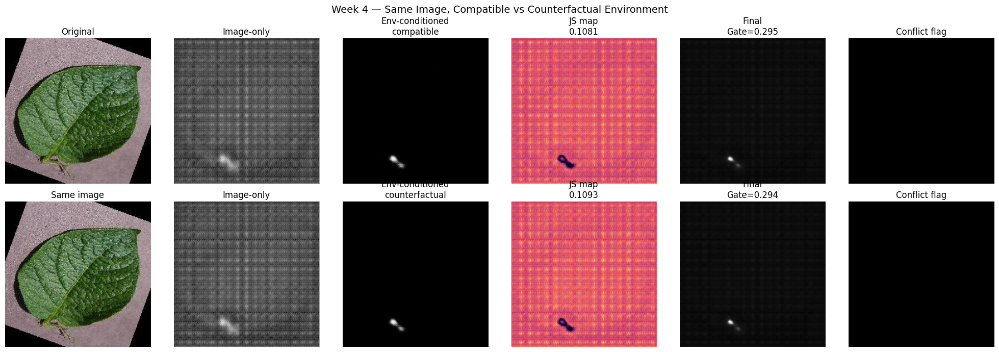


Filename: 101_Potato_Healthy_train_JPG.rf.140adb40478e116530cc9718b90080a1.jpg
Compatible candidate: 0
Counterfactual candidate: 3
Compatible learned gate: 0.2948777973651886
Counterfactual learned gate: 0.29421094059944153
Compatible JS: 0.10808141529560089
Counterfactual JS: 0.10932805389165878

Saved visualization: /content/week4_research/outputs/week4_same_image_counterfactual_visualization.png

DIAGNOSTIC CONCLUSION

Validation JS gap: -0.00013954192399978638
Test JS gap: 0.00033739954233169556
Validation prediction gap: 1.3381242752075195e-05
Test prediction gap: 0.0002561509609222412
Validation learned-gate gap: 4.9173831939697266e-05
Test learned-gate gap: -0.0002471506595611572

NOT YET VALIDATED:

The same-image counterfactual setup still does not produce
consistent positive JS/prediction disagreement separation
on both validation and test data.

Do not claim the disagreement-aware contribution as finally
validated yet.


Saved:
/content/week4_research/outputs/week4_same_ima

In [6]:
# =====================================================================
# WEEK 4 — SAME-IMAGE COUNTERFACTUAL ENVIRONMENT
# + DISAGREEMENT-AWARE FINE-TUNING
#
# RUN AFTER THE PREVIOUS WEEK 4 CELLS
# =====================================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image


# =====================================================================
# 0. CHECK REQUIRED VARIABLES
# =====================================================================

required_vars = [
    "model",
    "env_sequences_raw",
    "env_mean",
    "env_std",
    "train_df",
    "valid_df",
    "test_df",
    "train_transform",
    "valid_transform",
    "Week4Dataset"
]

missing = [
    x for x in required_vars
    if x not in globals()
]

if missing:
    raise RuntimeError(
        "Missing variables from previous Week 4 cell:\n"
        + "\n".join(missing)
        + "\n\nRun the previous Week 4 implementation first."
    )


# =====================================================================
# 1. CONFIG
# =====================================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

OUTPUT_DIR = "/content/week4_research/outputs"
os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

BASE_CHECKPOINT = os.path.join(
    OUTPUT_DIR,
    "week4_best_state_dict.pt"
)

FINAL_CHECKPOINT = os.path.join(
    OUTPUT_DIR,
    "week4_same_image_counterfactual_best.pt"
)

FINAL_CONFIG = os.path.join(
    OUTPUT_DIR,
    "week4_same_image_counterfactual_config.json"
)

PAIR_CSV = os.path.join(
    OUTPUT_DIR,
    "week4_same_image_counterfactual_pairs.csv"
)

HISTORY_CSV = os.path.join(
    OUTPUT_DIR,
    "week4_same_image_counterfactual_history.csv"
)

VIS_PATH = os.path.join(
    OUTPUT_DIR,
    "week4_same_image_counterfactual_visualization.png"
)

EPOCHS = 5
LR = 1e-5
BATCH_SIZE = 8
MAX_GRAD_NORM = 1.0

# Loss weights
W_ENV_SEG = 0.50
W_FUSED_SEG = 0.50
W_GATE = 1.00
W_JS_RANK = 1.00
W_PRED_RANK = 0.75
W_COMPAT_PULL = 0.10
W_MISMATCH_PUSH = 0.10

JS_MARGIN = 0.02
PRED_MARGIN = 0.03

COMPAT_JS_TARGET = 0.05
MISMATCH_JS_TARGET = 0.08

GATE_K = 35.0

print("=" * 78)
print("WEEK 4 — SAME-IMAGE COUNTERFACTUAL ENVIRONMENT")
print("=" * 78)
print("Device:", DEVICE)
print("Epochs:", EPOCHS)
print("LR:", LR)


# =====================================================================
# 2. LOAD ORIGINAL BEST WEEK-4 MODEL
#
# Do NOT start from the previous risk-aware donor-image checkpoint.
# We return to the clean original Week 4 checkpoint.
# =====================================================================

if not os.path.exists(BASE_CHECKPOINT):

    raise FileNotFoundError(
        f"Checkpoint not found:\n{BASE_CHECKPOINT}"
    )

base_state = torch.load(
    BASE_CHECKPOINT,
    map_location=DEVICE,
    weights_only=True
)

model.load_state_dict(
    base_state
)

model = model.to(DEVICE)

print(
    "\nLoaded original Week 4 best checkpoint:"
)

print(
    BASE_CHECKPOINT
)


# =====================================================================
# 3. NORMALIZE ALL ENVIRONMENT CANDIDATES
#
# env_sequences_raw contains candidate 0...9 for each image.
# Train-only env_mean/env_std from the previous pipeline are reused.
#
# This preserves the original normalization scheme.
# =====================================================================

normalized_all_env = {}

for key, seq in env_sequences_raw.items():

    seq = np.asarray(
        seq,
        dtype=np.float32
    )

    seq = (
        seq - env_mean
    ) / env_std

    seq = np.nan_to_num(
        seq,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    normalized_all_env[
        key
    ] = seq.astype(
        np.float32
    )


# =====================================================================
# 4. CANDIDATE INSPECTION
# =====================================================================

candidate_count = {}

for filename, candidate_id in normalized_all_env.keys():

    candidate_count.setdefault(
        filename,
        []
    )

    candidate_count[
        filename
    ].append(
        candidate_id
    )

candidate_numbers = [
    len(v)
    for v in candidate_count.values()
]

print(
    "\nCandidate statistics:"
)

print(
    "Number of images:",
    len(candidate_count)
)

print(
    "Candidates/image — min:",
    min(candidate_numbers)
)

print(
    "Candidates/image — max:",
    max(candidate_numbers)
)

print(
    "Candidates/image — mean:",
    np.mean(candidate_numbers)
)


# =====================================================================
# 5. ENVIRONMENT RISK PROXY FOR EACH CANDIDATE
#
# This is only used to select a counterfactual candidate.
#
# Features:
#   temperature
#   RH
#   rainfall
#   leaf wetness
#   soil moisture
#   RH>=90 indicator
#
# The risk proxy is:
#
#   0.50 * RH>=90 burden
# + 0.30 * wetness burden
# + 0.20 * rainfall burden
#
# This is NOT claimed as a validated disease-risk model.
# =====================================================================

candidate_stats = []

for key, seq in env_sequences_raw.items():

    filename, candidate_id = key

    seq = np.asarray(
        seq,
        dtype=np.float32
    )

    rh90_fraction = float(
        np.mean(
            seq[:, 5]
        )
    )

    rainfall_total = float(
        np.sum(
            seq[:, 2]
        )
    )

    wetness_total = float(
        np.sum(
            seq[:, 3]
        )
    )

    candidate_stats.append(
        {
            "filename": filename,
            "candidate_id": int(candidate_id),
            "rh90_fraction": rh90_fraction,
            "rainfall_total": rainfall_total,
            "wetness_total": wetness_total
        }
    )


candidate_stats_df = pd.DataFrame(
    candidate_stats
)


# Global percentile ranking.
def percentile_rank(values):

    values = np.asarray(
        values,
        dtype=np.float64
    )

    if len(values) <= 1:
        return np.zeros_like(
            values
        )

    order = np.argsort(
        np.argsort(values)
    )

    return (
        order /
        (len(values) - 1)
    )


candidate_stats_df[
    "rh_rank"
] = percentile_rank(
    candidate_stats_df[
        "rh90_fraction"
    ].values
)

candidate_stats_df[
    "wet_rank"
] = percentile_rank(
    candidate_stats_df[
        "wetness_total"
    ].values
)

candidate_stats_df[
    "rain_rank"
] = percentile_rank(
    candidate_stats_df[
        "rainfall_total"
    ].values
)

candidate_stats_df[
    "risk_score"
] = (
    0.50
    *
    candidate_stats_df[
        "rh_rank"
    ]
    +
    0.30
    *
    candidate_stats_df[
        "wet_rank"
    ]
    +
    0.20
    *
    candidate_stats_df[
        "rain_rank"
    ]
)


# Fast lookup.
risk_lookup = {}

for _, row in candidate_stats_df.iterrows():

    risk_lookup[
        (
            row["filename"],
            int(row["candidate_id"])
        )
    ] = float(
        row["risk_score"]
    )


# =====================================================================
# 6. SAME-IMAGE COUNTERFACTUAL MISMATCH MAP
#
# Compatible:
#   candidate_id = 0
#
# Mismatched:
#   candidate 1...9 from THE SAME IMAGE
#
# Choose the candidate with the greatest risk-score difference
# from candidate 0.
# =====================================================================

def build_same_image_mismatch_map(
    dataframe
):

    result = {}

    for filename in dataframe[
        "filename"
    ].tolist():

        compatible_key = (
            filename,
            0
        )

        if compatible_key not in normalized_all_env:

            raise RuntimeError(
                f"Candidate-0 environment missing for:\n{filename}"
            )

        compatible_risk = risk_lookup[
            compatible_key
        ]

        candidates = []

        for key in normalized_all_env.keys():

            candidate_filename, candidate_id = key

            if candidate_filename != filename:
                continue

            if int(candidate_id) == 0:
                continue

            if int(candidate_id) < 0:
                continue

            candidate_risk = risk_lookup.get(
                key,
                None
            )

            if candidate_risk is None:
                continue

            candidates.append(
                (
                    int(candidate_id),
                    float(candidate_risk)
                )
            )

        if len(candidates) == 0:

            raise RuntimeError(
                f"No counterfactual candidate found for:\n{filename}"
            )

        # Pick the candidate with the largest risk difference.
        selected_id, selected_risk = max(
            candidates,
            key=lambda x:
            abs(
                x[1] - compatible_risk
            )
        )

        result[
            filename
        ] = {
            "compatible_key":
                compatible_key,

            "mismatch_key":
                (
                    filename,
                    selected_id
                ),

            "compatible_risk":
                compatible_risk,

            "mismatch_risk":
                selected_risk,

            "risk_distance":
                abs(
                    selected_risk
                    -
                    compatible_risk
                )
        }

    return result


train_pair_map = build_same_image_mismatch_map(
    train_df
)

valid_pair_map = build_same_image_mismatch_map(
    valid_df
)

test_pair_map = build_same_image_mismatch_map(
    test_df
)


# =====================================================================
# 7. PAIR TABLE
# =====================================================================

pair_rows = []

for split_name, dataframe, pair_map in [
    ("train", train_df, train_pair_map),
    ("valid", valid_df, valid_pair_map),
    ("test", test_df, test_pair_map)
]:

    for filename in dataframe[
        "filename"
    ].tolist():

        pair = pair_map[
            filename
        ]

        pair_rows.append(
            {
                "split":
                    split_name,

                "filename":
                    filename,

                "compatible_candidate":
                    0,

                "mismatched_candidate":
                    pair[
                        "mismatch_key"
                    ][1],

                "compatible_risk":
                    pair[
                        "compatible_risk"
                    ],

                "mismatch_risk":
                    pair[
                        "mismatch_risk"
                    ],

                "risk_distance":
                    pair[
                        "risk_distance"
                    ]
            }
        )


pair_table = pd.DataFrame(
    pair_rows
)

pair_table.to_csv(
    PAIR_CSV,
    index=False
)

print(
    "\nSame-image mismatch pairs:"
)

print(
    pair_table.groupby(
        "split"
    ).size()
)

print(
    "\nMean risk distance:"
)

print(
    pair_table.groupby(
        "split"
    )["risk_distance"].mean()
)


# =====================================================================
# 8. NEW DATASET
# =====================================================================

class SameImageCounterfactualDataset(
    Dataset
):

    def __init__(
        self,
        dataframe,
        pair_map,
        transform
    ):

        self.df = dataframe.reset_index(
            drop=True
        )

        self.pair_map = pair_map

        self.transform = transform


    def __len__(self):

        return len(
            self.df
        )


    def __getitem__(
        self,
        idx
    ):

        row = self.df.iloc[
            idx
        ]

        filename = row[
            "filename"
        ]

        image = np.array(
            Image.open(
                row["image_path"]
            ).convert("RGB")
        )

        mask = np.array(
            Image.open(
                row["mask_path"]
            ).convert("L")
        )

        mask = (
            mask > 0
        ).astype(
            np.float32
        )

        if self.transform is not None:

            transformed = self.transform(
                image=image,
                mask=mask
            )

            image = transformed[
                "image"
            ]

            mask = transformed[
                "mask"
            ]

        if mask.ndim == 2:

            mask = mask.unsqueeze(
                0
            )

        pair = self.pair_map[
            filename
        ]

        compatible_key = pair[
            "compatible_key"
        ]

        mismatch_key = pair[
            "mismatch_key"
        ]

        env_compatible = torch.tensor(
            normalized_all_env[
                compatible_key
            ],
            dtype=torch.float32
        )

        env_mismatch = torch.tensor(
            normalized_all_env[
                mismatch_key
            ],
            dtype=torch.float32
        )

        return {
            "image":
                image,

            "mask":
                mask.float(),

            "environment_compatible":
                env_compatible,

            "environment_mismatch":
                env_mismatch,

            "filename":
                filename,

            "compatible_candidate":
                torch.tensor(
                    compatible_key[1],
                    dtype=torch.long
                ),

            "mismatch_candidate":
                torch.tensor(
                    mismatch_key[1],
                    dtype=torch.long
                )
        }


# =====================================================================
# 9. DATALOADERS
# =====================================================================

same_train_ds = SameImageCounterfactualDataset(
    train_df,
    train_pair_map,
    train_transform
)

same_valid_ds = SameImageCounterfactualDataset(
    valid_df,
    valid_pair_map,
    valid_transform
)

same_test_ds = SameImageCounterfactualDataset(
    test_df,
    test_pair_map,
    valid_transform
)


same_train_loader = DataLoader(
    same_train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

same_valid_loader = DataLoader(
    same_valid_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

same_test_loader = DataLoader(
    same_test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(
    "\nSame-image counterfactual dataloaders ready."
)


# =====================================================================
# 10. HELPER — FORWARD PAIR
# =====================================================================

def forward_same_image_pair(
    model,
    batch
):

    images = batch[
        "image"
    ].to(
        DEVICE,
        non_blocking=True
    )

    env_c = batch[
        "environment_compatible"
    ].to(
        DEVICE,
        non_blocking=True
    )

    env_m = batch[
        "environment_mismatch"
    ].to(
        DEVICE,
        non_blocking=True
    )

    z = model.encode_image(
        images
    )

    image_feat = model.image_features(
        z
    )

    out_c = model.predict_from_features(
        z,
        image_feat,
        env_c
    )

    out_m = model.predict_from_features(
        z,
        image_feat,
        env_m
    )

    return (
        images,
        env_c,
        env_m,
        out_c,
        out_m
    )


# =====================================================================
# 11. TRAINING LOSS
# =====================================================================

def same_image_conflict_loss(
    out_c,
    out_m
):

    image_prob_c = out_c[
        "image_prob"
    ].float()

    env_prob_c = out_c[
        "environment_prob"
    ].float()

    env_prob_m = out_m[
        "environment_prob"
    ].float()

    # ---------------------------------------------------------------
    # Prediction disagreement
    #
    # Compatible:
    #   image branch and environment branch should remain similar.
    #
    # Mismatch:
    #   environment-conditioned branch should move away from
    #   the image-only prediction.
    # ---------------------------------------------------------------
    pred_diff_c = torch.mean(
        torch.abs(
            image_prob_c
            -
            env_prob_c
        ),
        dim=(1, 2, 3)
    )

    pred_diff_m = torch.mean(
        torch.abs(
            image_prob_c
            -
            env_prob_m
        ),
        dim=(1, 2, 3)
    )

    pred_rank = F.relu(
        PRED_MARGIN
        +
        pred_diff_c
        -
        pred_diff_m
    ).mean()

    # ---------------------------------------------------------------
    # JS disagreement
    # ---------------------------------------------------------------
    js_c = out_c[
        "js_score"
    ].float()

    js_m = out_m[
        "js_score"
    ].float()

    js_rank = F.relu(
        JS_MARGIN
        +
        js_c
        -
        js_m
    ).mean()

    # ---------------------------------------------------------------
    # Compatible JS regularization
    # ---------------------------------------------------------------
    compat_pull = F.relu(
        js_c
        -
        COMPAT_JS_TARGET
    ).pow(
        2
    ).mean()

    # ---------------------------------------------------------------
    # Mismatch JS target
    # ---------------------------------------------------------------
    mismatch_push = F.relu(
        MISMATCH_JS_TARGET
        -
        js_m
    ).pow(
        2
    ).mean()

    # ---------------------------------------------------------------
    # Direct gate supervision
    # ---------------------------------------------------------------
    gate_logits = torch.cat(
        [
            out_c[
                "gate_logit"
            ],
            out_m[
                "gate_logit"
            ]
        ],
        dim=0
    ).float()

    gate_targets = torch.cat(
        [
            torch.zeros_like(
                out_c[
                    "gate_logit"
                ]
            ),
            torch.ones_like(
                out_m[
                    "gate_logit"
                ]
            )
        ],
        dim=0
    ).float()

    gate_loss = (
        F.binary_cross_entropy_with_logits(
            gate_logits,
            gate_targets
        )
    )

    return {
        "gate":
            gate_loss,

        "js_rank":
            js_rank,

        "pred_rank":
            pred_rank,

        "compat_pull":
            compat_pull,

        "mismatch_push":
            mismatch_push,

        "pred_diff_c":
            pred_diff_c.mean(),

        "pred_diff_m":
            pred_diff_m.mean(),

        "js_c":
            js_c.mean(),

        "js_m":
            js_m.mean()
    }


# =====================================================================
# 12. TRAINABLE PARAMETERS
#
# Keep the existing visual representation stable.
# Tune only environment conditioning + fused/gate components.
# =====================================================================

for p in model.parameters():

    p.requires_grad = False


trainable_prefixes = [
    "environment_encoder",
    "film4",
    "film3",
    "film2",
    "film1",
    "environment_head",
    "fused_head",
    "gate_mlp"
]


for name, p in model.named_parameters():

    if any(
        name.startswith(prefix)
        for prefix in trainable_prefixes
    ):

        p.requires_grad = True


trainable_params = [
    p
    for p in model.parameters()
    if p.requires_grad
]


print(
    "\nTrainable parameters:",
    sum(
        p.numel()
        for p in trainable_params
    )
)


optimizer = torch.optim.AdamW(
    trainable_params,
    lr=LR,
    weight_decay=1e-4
)


# =====================================================================
# 13. VALIDATION FUNCTION
# =====================================================================

@torch.no_grad()
def evaluate_pairs(
    model,
    loader
):

    model.eval()

    result = {
        "js_c": [],
        "js_m": [],
        "gate_c": [],
        "gate_m": [],
        "pred_diff_c": [],
        "pred_diff_m": [],
        "fused_shift": [],
        "env_shift": []
    }

    for batch in loader:

        (
            images,
            env_c,
            env_m,
            out_c,
            out_m
        ) = forward_same_image_pair(
            model,
            batch
        )

        image_prob = out_c[
            "image_prob"
        ].float()

        env_prob_c = out_c[
            "environment_prob"
        ].float()

        env_prob_m = out_m[
            "environment_prob"
        ].float()

        fused_prob_c = torch.sigmoid(
            out_c[
                "fused_logits"
            ].float()
        )

        fused_prob_m = torch.sigmoid(
            out_m[
                "fused_logits"
            ].float()
        )

        pred_diff_c = torch.mean(
            torch.abs(
                image_prob
                -
                env_prob_c
            ),
            dim=(1, 2, 3)
        )

        pred_diff_m = torch.mean(
            torch.abs(
                image_prob
                -
                env_prob_m
            ),
            dim=(1, 2, 3)
        )

        env_shift = torch.mean(
            torch.abs(
                env_prob_c
                -
                env_prob_m
            ),
            dim=(1, 2, 3)
        )

        fused_shift = torch.mean(
            torch.abs(
                fused_prob_c
                -
                fused_prob_m
            ),
            dim=(1, 2, 3)
        )

        result[
            "js_c"
        ].extend(
            out_c[
                "js_score"
            ].cpu().numpy()
        )

        result[
            "js_m"
        ].extend(
            out_m[
                "js_score"
            ].cpu().numpy()
        )

        result[
            "gate_c"
        ].extend(
            out_c[
                "learned_gate"
            ].cpu().numpy()
        )

        result[
            "gate_m"
        ].extend(
            out_m[
                "learned_gate"
            ].cpu().numpy()
        )

        result[
            "pred_diff_c"
        ].extend(
            pred_diff_c.cpu().numpy()
        )

        result[
            "pred_diff_m"
        ].extend(
            pred_diff_m.cpu().numpy()
        )

        result[
            "env_shift"
        ].extend(
            env_shift.cpu().numpy()
        )

        result[
            "fused_shift"
        ].extend(
            fused_shift.cpu().numpy()
        )

    for key in result:

        result[key] = np.asarray(
            result[key],
            dtype=np.float32
        )

    return result


# =====================================================================
# 14. BASELINE DIAGNOSTIC BEFORE TRAINING
# =====================================================================

print("\n" + "=" * 78)
print("BASELINE — SAME IMAGE / COUNTERFACTUAL CANDIDATE")
print("=" * 78)

model.eval()

baseline_valid = evaluate_pairs(
    model,
    same_valid_loader
)

baseline_test = evaluate_pairs(
    model,
    same_test_loader
)


def print_pair_stats(
    name,
    stats
):

    print(
        "\n" + name
    )

    print(
        "Compatible JS:",
        float(
            stats["js_c"].mean()
        )
    )

    print(
        "Mismatched JS:",
        float(
            stats["js_m"].mean()
        )
    )

    print(
        "JS gap (M-C):",
        float(
            stats["js_m"].mean()
            -
            stats["js_c"].mean()
        )
    )

    print(
        "Compatible prediction diff:",
        float(
            stats["pred_diff_c"].mean()
        )
    )

    print(
        "Mismatched prediction diff:",
        float(
            stats["pred_diff_m"].mean()
        )
    )

    print(
        "Prediction-difference gap:",
        float(
            stats["pred_diff_m"].mean()
            -
            stats["pred_diff_c"].mean()
        )
    )

    print(
        "Environment prediction shift:",
        float(
            stats["env_shift"].mean()
        )
    )

    print(
        "Fused prediction shift:",
        float(
            stats["fused_shift"].mean()
        )
    )

    print(
        "Compatible learned gate:",
        float(
            stats["gate_c"].mean()
        )
    )

    print(
        "Mismatched learned gate:",
        float(
            stats["gate_m"].mean()
        )
    )


print_pair_stats(
    "VALIDATION",
    baseline_valid
)

print_pair_stats(
    "TEST",
    baseline_test
)


# =====================================================================
# 15. TRAINING
# =====================================================================

best_score = float(
    "inf"
)

history = []

print("\n" + "=" * 78)
print("SAME-IMAGE COUNTERFACTUAL FINE-TUNING")
print("=" * 78)


for epoch in range(
    1,
    EPOCHS + 1
):

    model.train()

    epoch_losses = []

    print(
        f"\nEpoch {epoch}/{EPOCHS}"
    )

    for batch_idx, batch in enumerate(
        same_train_loader
    ):

        masks = batch[
            "mask"
        ].to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        (
            images,
            env_c,
            env_m,
            out_c,
            out_m
        ) = forward_same_image_pair(
            model,
            batch
        )

        # -----------------------------------------------------------
        # Compatible segmentation only.
        # Mismatched environment is counterfactual.
        # -----------------------------------------------------------
        env_seg_loss = (
            segmentation_loss(
                out_c[
                    "environment_logits"
                ],
                masks
            )
        )

        fused_seg_loss = (
            segmentation_loss(
                out_c[
                    "fused_logits"
                ],
                masks
            )
        )

        conflict = same_image_conflict_loss(
            out_c,
            out_m
        )

        total_loss = (
            W_ENV_SEG
            *
            env_seg_loss

            +

            W_FUSED_SEG
            *
            fused_seg_loss

            +

            W_GATE
            *
            conflict["gate"]

            +

            W_JS_RANK
            *
            conflict["js_rank"]

            +

            W_PRED_RANK
            *
            conflict["pred_rank"]

            +

            W_COMPAT_PULL
            *
            conflict["compat_pull"]

            +

            W_MISMATCH_PUSH
            *
            conflict["mismatch_push"]
        )

        if not torch.isfinite(
            total_loss
        ):

            print(
                f"Skipping non-finite batch "
                f"{batch_idx}"
            )

            continue

        total_loss.backward()

        grad_norm = torch.nn.utils.clip_grad_norm_(
            trainable_params,
            MAX_GRAD_NORM,
            error_if_nonfinite=False
        )

        if not torch.isfinite(
            torch.as_tensor(
                grad_norm
            )
        ):

            print(
                f"Skipping non-finite gradient "
                f"batch {batch_idx}"
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            continue

        optimizer.step()

        epoch_losses.append(
            total_loss.item()
        )

        if batch_idx % 20 == 0:

            print(
                f"Batch {batch_idx:03d} | "
                f"Total {total_loss.item():.4f} | "
                f"EnvSeg {env_seg_loss.item():.4f} | "
                f"Fused {fused_seg_loss.item():.4f} | "
                f"Gate {conflict['gate'].item():.4f} | "
                f"JSrank {conflict['js_rank'].item():.4f} | "
                f"PredRank {conflict['pred_rank'].item():.4f} | "
                f"JS-C {conflict['js_c'].item():.4f} | "
                f"JS-M {conflict['js_m'].item():.4f} | "
                f"Diff-C {conflict['pred_diff_c'].item():.4f} | "
                f"Diff-M {conflict['pred_diff_m'].item():.4f}"
            )

    # ---------------------------------------------------------------
    # Validation
    # ---------------------------------------------------------------
    val_stats = evaluate_pairs(
        model,
        same_valid_loader
    )

    val_seg_losses = []

    model.eval()

    with torch.no_grad():

        for batch in same_valid_loader:

            masks = batch[
                "mask"
            ].to(
                DEVICE
            )

            (
                images,
                env_c,
                env_m,
                out_c,
                out_m
            ) = forward_same_image_pair(
                model,
                batch
            )

            val_seg_losses.append(
                segmentation_loss(
                    out_c[
                        "fused_logits"
                    ],
                    masks
                ).item()
            )

    val_seg = float(
        np.mean(
            val_seg_losses
        )
    )

    js_gap = float(
        val_stats["js_m"].mean()
        -
        val_stats["js_c"].mean()
    )

    pred_gap = float(
        val_stats["pred_diff_m"].mean()
        -
        val_stats["pred_diff_c"].mean()
    )

    gate_gap = float(
        val_stats["gate_m"].mean()
        -
        val_stats["gate_c"].mean()
    )

    # Lower segmentation is good.
    # Larger positive disagreement gaps are good.
    # Penalize negative gaps.
    score = (
        val_seg

        +
        0.50
        *
        max(
            0.0,
            -js_gap
        )

        +
        0.50
        *
        max(
            0.0,
            -pred_gap
        )

        +
        0.20
        *
        max(
            0.0,
            -gate_gap
        )
    )

    print(
        "\nValidation:"
    )

    print(
        "Fused segmentation loss:",
        val_seg
    )

    print(
        "Compatible JS:",
        float(
            val_stats["js_c"].mean()
        )
    )

    print(
        "Mismatched JS:",
        float(
            val_stats["js_m"].mean()
        )
    )

    print(
        "JS gap:",
        js_gap
    )

    print(
        "Compatible prediction diff:",
        float(
            val_stats["pred_diff_c"].mean()
        )
    )

    print(
        "Mismatched prediction diff:",
        float(
            val_stats["pred_diff_m"].mean()
        )
    )

    print(
        "Prediction gap:",
        pred_gap
    )

    print(
        "Environment prediction shift:",
        float(
            val_stats["env_shift"].mean()
        )
    )

    print(
        "Compatible gate:",
        float(
            val_stats["gate_c"].mean()
        )
    )

    print(
        "Mismatched gate:",
        float(
            val_stats["gate_m"].mean()
        )
    )

    print(
        "Gate gap:",
        gate_gap
    )

    history.append(
        {
            "epoch":
                epoch,

            "train_loss":
                float(
                    np.mean(
                        epoch_losses
                    )
                ),

            "val_seg":
                val_seg,

            "js_c":
                float(
                    val_stats["js_c"].mean()
                ),

            "js_m":
                float(
                    val_stats["js_m"].mean()
                ),

            "js_gap":
                js_gap,

            "pred_diff_c":
                float(
                    val_stats[
                        "pred_diff_c"
                    ].mean()
                ),

            "pred_diff_m":
                float(
                    val_stats[
                        "pred_diff_m"
                    ].mean()
                ),

            "pred_gap":
                pred_gap,

            "gate_c":
                float(
                    val_stats[
                        "gate_c"
                    ].mean()
                ),

            "gate_m":
                float(
                    val_stats[
                        "gate_m"
                    ].mean()
                ),

            "gate_gap":
                gate_gap,

            "env_shift":
                float(
                    val_stats[
                        "env_shift"
                    ].mean()
                )
        }
    )

    if (
        np.isfinite(score)
        and
        score < best_score
    ):

        best_score = score

        torch.save(
            model.state_dict(),
            FINAL_CHECKPOINT
        )

        print(
            "✓ Best same-image model saved."
        )


# =====================================================================
# 16. SAVE HISTORY
# =====================================================================

history_df = pd.DataFrame(
    history
)

history_df.to_csv(
    HISTORY_CSV,
    index=False
)


# =====================================================================
# 17. LOAD BEST SAME-IMAGE MODEL
# =====================================================================

if not os.path.exists(
    FINAL_CHECKPOINT
):

    raise RuntimeError(
        "No valid same-image checkpoint was saved."
    )

model.load_state_dict(
    torch.load(
        FINAL_CHECKPOINT,
        map_location=DEVICE,
        weights_only=True
    )
)

model = model.to(
    DEVICE
)

model.eval()

print(
    "\nLoaded best same-image checkpoint:"
)

print(
    FINAL_CHECKPOINT
)


# =====================================================================
# 18. FINAL VALIDATION / TEST
# =====================================================================

final_valid = evaluate_pairs(
    model,
    same_valid_loader
)

final_test = evaluate_pairs(
    model,
    same_test_loader
)


# =====================================================================
# 19. JS THRESHOLD
#
# 95th percentile of COMPATIBLE validation JS only.
# =====================================================================

JS_THRESHOLD = float(
    np.percentile(
        final_valid[
            "js_c"
        ],
        95
    )
)


def deterministic_js_gate(
    js_values,
    threshold
):

    js_values = np.asarray(
        js_values,
        dtype=np.float32
    )

    return 1.0 / (
        1.0
        +
        np.exp(
            -GATE_K
            *
            (
                js_values
                -
                threshold
            )
        )
    )


valid_js_gate_c = deterministic_js_gate(
    final_valid["js_c"],
    JS_THRESHOLD
)

valid_js_gate_m = deterministic_js_gate(
    final_valid["js_m"],
    JS_THRESHOLD
)

test_js_gate_c = deterministic_js_gate(
    final_test["js_c"],
    JS_THRESHOLD
)

test_js_gate_m = deterministic_js_gate(
    final_test["js_m"],
    JS_THRESHOLD
)


# =====================================================================
# 20. FINAL REPORT
# =====================================================================

print("\n" + "=" * 78)
print("FINAL SAME-IMAGE COUNTERFACTUAL RESULTS")
print("=" * 78)

print(
    "\nJS threshold:",
    JS_THRESHOLD
)


def report(
    name,
    stats,
    js_gate_c,
    js_gate_m
):

    print(
        "\n" + name
    )

    print(
        "Compatible JS:",
        float(
            stats["js_c"].mean()
        )
    )

    print(
        "Mismatched JS:",
        float(
            stats["js_m"].mean()
        )
    )

    print(
        "JS gap (M-C):",
        float(
            stats["js_m"].mean()
            -
            stats["js_c"].mean()
        )
    )

    print(
        "Compatible prediction diff:",
        float(
            stats[
                "pred_diff_c"
            ].mean()
        )
    )

    print(
        "Mismatched prediction diff:",
        float(
            stats[
                "pred_diff_m"
            ].mean()
        )
    )

    print(
        "Prediction gap:",
        float(
            stats[
                "pred_diff_m"
            ].mean()
            -
            stats[
                "pred_diff_c"
            ].mean()
        )
    )

    print(
        "Environment prediction shift:",
        float(
            stats[
                "env_shift"
            ].mean()
        )
    )

    print(
        "Compatible learned gate:",
        float(
            stats[
                "gate_c"
            ].mean()
        )
    )

    print(
        "Mismatched learned gate:",
        float(
            stats[
                "gate_m"
            ].mean()
        )
    )

    print(
        "Learned gate gap:",
        float(
            stats[
                "gate_m"
            ].mean()
            -
            stats[
                "gate_c"
            ].mean()
        )
    )

    print(
        "JS-gate compatible mean:",
        float(
            js_gate_c.mean()
        )
    )

    print(
        "JS-gate mismatched mean:",
        float(
            js_gate_m.mean()
        )
    )

    print(
        "JS conflict rate — compatible:",
        100.0
        *
        float(
            np.mean(
                stats["js_c"]
                >=
                JS_THRESHOLD
            )
        ),
        "%"
    )

    print(
        "JS conflict rate — mismatched:",
        100.0
        *
        float(
            np.mean(
                stats["js_m"]
                >=
                JS_THRESHOLD
            )
        ),
        "%"
    )


report(
    "VALIDATION",
    final_valid,
    valid_js_gate_c,
    valid_js_gate_m
)

report(
    "TEST",
    final_test,
    test_js_gate_c,
    test_js_gate_m
)


# =====================================================================
# 21. ARTIFICIAL JS GATE TEST
# =====================================================================

print(
    "\n" + "=" * 78
)

print(
    "DETERMINISTIC JS GATE UNIT TESTS"
)

print(
    "=" * 78
)

identical_js = np.zeros(
    32,
    dtype=np.float32
)

strong_js = np.ones(
    32,
    dtype=np.float32
) * 0.6931

partial_js = np.concatenate(
    [
        np.zeros(16),
        np.ones(16)
        *
        0.685
    ]
).astype(
    np.float32
)

g_identical = deterministic_js_gate(
    identical_js,
    JS_THRESHOLD
)

g_strong = deterministic_js_gate(
    strong_js,
    JS_THRESHOLD
)

g_partial = deterministic_js_gate(
    partial_js,
    JS_THRESHOLD
)

print(
    "\nIdentical:"
)

print(
    "JS gate:",
    float(
        g_identical.mean()
    )
)

print(
    "\nStrong conflict:"
)

print(
    "JS gate:",
    float(
        g_strong.mean()
    )
)

print(
    "\nPartial conflict:"
)

print(
    "Agreement region:",
    float(
        g_partial[:16].mean()
    )
)

print(
    "Conflict region:",
    float(
        g_partial[16:].mean()
    )
)


assert (
    g_identical.mean()
    < 0.20
)

assert (
    g_strong.mean()
    > 0.95
)

assert (
    g_partial[16:].mean()
    >
    g_partial[:16].mean()
)

print(
    "\nPASS — deterministic JS gate tests."
)


# =====================================================================
# 22. SAME-IMAGE VISUALIZATION
# =====================================================================

@torch.no_grad()
def visualize_same_image(
    model,
    dataset,
    index=0
):

    model.eval()

    sample = dataset[
        index
    ]

    image = sample[
        "image"
    ].unsqueeze(
        0
    ).to(
        DEVICE
    )

    env_c = sample[
        "environment_compatible"
    ].unsqueeze(
        0
    ).to(
        DEVICE
    )

    env_m = sample[
        "environment_mismatch"
    ].unsqueeze(
        0
    ).to(
        DEVICE
    )

    z = model.encode_image(
        image
    )

    image_feat = model.image_features(
        z
    )

    out_c = model.predict_from_features(
        z,
        image_feat,
        env_c
    )

    out_m = model.predict_from_features(
        z,
        image_feat,
        env_m
    )

    # ---------------------------------------------------------------
    # Image display
    # ---------------------------------------------------------------
    display = (
        image[
            0
        ]
        .detach()
        .cpu()
        .permute(
            1,
            2,
            0
        )
        .numpy()
    )

    mean = np.array(
        [
            0.485,
            0.456,
            0.406
        ]
    )

    std = np.array(
        [
            0.229,
            0.224,
            0.225
        ]
    )

    display = (
        display * std
        +
        mean
    )

    display = np.clip(
        display,
        0,
        1
    )

    # ---------------------------------------------------------------
    # Predictions
    # ---------------------------------------------------------------
    image_pred = torch.sigmoid(
        out_c[
            "image_logits"
        ].float()
    )[0, 0].cpu().numpy()

    env_pred_c = torch.sigmoid(
        out_c[
            "environment_logits"
        ].float()
    )[0, 0].cpu().numpy()

    env_pred_m = torch.sigmoid(
        out_m[
            "environment_logits"
        ].float()
    )[0, 0].cpu().numpy()

    fused_pred_c = torch.sigmoid(
        out_c[
            "fused_logits"
        ].float()
    )[0, 0].cpu().numpy()

    fused_pred_m = torch.sigmoid(
        out_m[
            "fused_logits"
        ].float()
    )[0, 0].cpu().numpy()

    js_c = out_c[
        "js_map"
    ][0, 0].cpu().numpy()

    js_m = out_m[
        "js_map"
    ][0, 0].cpu().numpy()

    gate_c = float(
        out_c[
            "learned_gate"
        ].item()
    )

    gate_m = float(
        out_m[
            "learned_gate"
        ].item()
    )

    # ---------------------------------------------------------------
    # Final routing:
    #
    # low conflict:
    #     fused prediction
    #
    # high conflict:
    #     image-only fallback
    # ---------------------------------------------------------------
    final_c = (
        (
            1.0
            -
            gate_c
        )
        *
        fused_pred_c
        +
        gate_c
        *
        image_pred
    )

    final_m = (
        (
            1.0
            -
            gate_m
        )
        *
        fused_pred_m
        +
        gate_m
        *
        image_pred
    )

    flag_c = gate_c >= 0.5
    flag_m = gate_m >= 0.5

    # ---------------------------------------------------------------
    # Plot
    # ---------------------------------------------------------------
    fig, axes = plt.subplots(
        2,
        6,
        figsize=(
            20,
            7
        )
    )

    # ===============================================================
    # Compatible row
    # ===============================================================
    axes[0, 0].imshow(
        display
    )

    axes[0, 0].set_title(
        "Original"
    )

    axes[0, 1].imshow(
        image_pred,
        cmap="gray"
    )

    axes[0, 1].set_title(
        "Image-only"
    )

    axes[0, 2].imshow(
        env_pred_c,
        cmap="gray"
    )

    axes[0, 2].set_title(
        "Env-conditioned\ncompatible"
    )

    axes[0, 3].imshow(
        js_c,
        cmap="magma"
    )

    axes[0, 3].set_title(
        f"JS map\n{js_c.mean():.4f}"
    )

    axes[0, 4].imshow(
        final_c,
        cmap="gray"
    )

    axes[0, 4].set_title(
        f"Final\nGate={gate_c:.3f}"
    )

    axes[0, 5].imshow(
        np.ones_like(
            js_c
        )
        *
        flag_c,
        cmap="gray"
    )

    axes[0, 5].set_title(
        "Conflict flag"
    )

    # ===============================================================
    # Mismatch row
    # ===============================================================
    axes[1, 0].imshow(
        display
    )

    axes[1, 0].set_title(
        "Same image"
    )

    axes[1, 1].imshow(
        image_pred,
        cmap="gray"
    )

    axes[1, 1].set_title(
        "Image-only"
    )

    axes[1, 2].imshow(
        env_pred_m,
        cmap="gray"
    )

    axes[1, 2].set_title(
        "Env-conditioned\ncounterfactual"
    )

    axes[1, 3].imshow(
        js_m,
        cmap="magma"
    )

    axes[1, 3].set_title(
        f"JS map\n{js_m.mean():.4f}"
    )

    axes[1, 4].imshow(
        final_m,
        cmap="gray"
    )

    axes[1, 4].set_title(
        f"Final\nGate={gate_m:.3f}"
    )

    axes[1, 5].imshow(
        np.ones_like(
            js_m
        )
        *
        flag_m,
        cmap="gray"
    )

    axes[1, 5].set_title(
        "Conflict flag"
    )

    for ax in axes.flat:
        ax.axis(
            "off"
        )

    fig.suptitle(
        "Week 4 — Same Image, Compatible vs Counterfactual Environment",
        fontsize=14
    )

    plt.tight_layout()

    plt.savefig(
        VIS_PATH,
        dpi=180,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "\nFilename:",
        sample["filename"]
    )

    print(
        "Compatible candidate:",
        int(
            sample[
                "compatible_candidate"
            ].item()
        )
    )

    print(
        "Counterfactual candidate:",
        int(
            sample[
                "mismatch_candidate"
            ].item()
        )
    )

    print(
        "Compatible learned gate:",
        gate_c
    )

    print(
        "Counterfactual learned gate:",
        gate_m
    )

    print(
        "Compatible JS:",
        float(
            js_c.mean()
        )
    )

    print(
        "Counterfactual JS:",
        float(
            js_m.mean()
        )
    )

    print(
        "\nSaved visualization:",
        VIS_PATH
    )


visualize_same_image(
    model,
    same_valid_ds,
    index=0
)


# =====================================================================
# 23. AUTOMATIC CONCLUSION
# =====================================================================

valid_js_gap = float(
    final_valid["js_m"].mean()
    -
    final_valid["js_c"].mean()
)

test_js_gap = float(
    final_test["js_m"].mean()
    -
    final_test["js_c"].mean()
)

valid_pred_gap = float(
    final_valid["pred_diff_m"].mean()
    -
    final_valid["pred_diff_c"].mean()
)

test_pred_gap = float(
    final_test["pred_diff_m"].mean()
    -
    final_test["pred_diff_c"].mean()
)

valid_gate_gap = float(
    final_valid["gate_m"].mean()
    -
    final_valid["gate_c"].mean()
)

test_gate_gap = float(
    final_test["gate_m"].mean()
    -
    final_test["gate_c"].mean()
)


print("\n" + "=" * 78)
print("DIAGNOSTIC CONCLUSION")
print("=" * 78)

print(
    "\nValidation JS gap:",
    valid_js_gap
)

print(
    "Test JS gap:",
    test_js_gap
)

print(
    "Validation prediction gap:",
    valid_pred_gap
)

print(
    "Test prediction gap:",
    test_pred_gap
)

print(
    "Validation learned-gate gap:",
    valid_gate_gap
)

print(
    "Test learned-gate gap:",
    test_gate_gap
)


if (
    valid_js_gap > 0
    and
    test_js_gap > 0
    and
    valid_pred_gap > 0
    and
    test_pred_gap > 0
):

    print(
        """
PASS:

The same-image counterfactual setup produced the desired
direction of environment-conditioned disagreement on both
validation and held-out test data.
"""
    )

else:

    print(
        """
NOT YET VALIDATED:

The same-image counterfactual setup still does not produce
consistent positive JS/prediction disagreement separation
on both validation and test data.

Do not claim the disagreement-aware contribution as finally
validated yet.
"""
    )


# =====================================================================
# 24. SAVE FINAL CONFIG
# =====================================================================

config = {
    "checkpoint":
        FINAL_CHECKPOINT,

    "js_threshold":
        JS_THRESHOLD,

    "epochs":
        EPOCHS,

    "learning_rate":
        LR,

    "same_image_counterfactual":
        True,

    "compatible_candidate":
        0,

    "mismatch_candidates":
        "1-9",

    "validation_js_gap":
        valid_js_gap,

    "test_js_gap":
        test_js_gap,

    "validation_prediction_gap":
        valid_pred_gap,

    "test_prediction_gap":
        test_pred_gap,

    "validation_gate_gap":
        valid_gate_gap,

    "test_gate_gap":
        test_gate_gap
}

with open(
    FINAL_CONFIG,
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=2
    )


print(
    "\nSaved:"
)

print(
    FINAL_CHECKPOINT
)

print(
    PAIR_CSV
)

print(
    HISTORY_CSV
)

print(
    VIS_PATH
)

print(
    FINAL_CONFIG
)

print(
    "\nWEEK 4 SAME-IMAGE COUNTERFACTUAL EXPERIMENT FINISHED."
)

# **again**

In [7]:
# =====================================================================
# WEEK 4 — ENVIRONMENT CONDITIONING DIAGNOSTIC
# NO TRAINING
# =====================================================================

import os
import copy
import numpy as np
import torch
import torch.nn.functional as F

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

OUTPUT_DIR = "/content/week4_research/outputs"

BASE_CHECKPOINT = os.path.join(
    OUTPUT_DIR,
    "week4_best_state_dict.pt"
)

COUNTERFACTUAL_CHECKPOINT = os.path.join(
    OUTPUT_DIR,
    "week4_same_image_counterfactual_best.pt"
)

# -------------------------------------------------------------
# Check files
# -------------------------------------------------------------
assert os.path.exists(BASE_CHECKPOINT), (
    f"Missing:\n{BASE_CHECKPOINT}"
)

assert os.path.exists(COUNTERFACTUAL_CHECKPOINT), (
    f"Missing:\n{COUNTERFACTUAL_CHECKPOINT}"
)

# -------------------------------------------------------------
# Load two copies of the same architecture
# -------------------------------------------------------------
base_model = copy.deepcopy(model).to(DEVICE)
counter_model = copy.deepcopy(model).to(DEVICE)

base_model.load_state_dict(
    torch.load(
        BASE_CHECKPOINT,
        map_location=DEVICE,
        weights_only=True
    )
)

counter_model.load_state_dict(
    torch.load(
        COUNTERFACTUAL_CHECKPOINT,
        map_location=DEVICE,
        weights_only=True
    )
)

base_model.eval()
counter_model.eval()

print("=" * 78)
print("ENVIRONMENT CONDITIONING DIAGNOSTIC")
print("=" * 78)


# -------------------------------------------------------------
# Get one validation batch
# -------------------------------------------------------------
batch = next(
    iter(same_valid_loader)
)

images = batch[
    "image"
].to(
    DEVICE
)

env_c = batch[
    "environment_compatible"
].to(
    DEVICE
)

env_m = batch[
    "environment_mismatch"
].to(
    DEVICE
)


# -------------------------------------------------------------
# Helper
# -------------------------------------------------------------
@torch.no_grad()
def inspect_model(
    net,
    images,
    env_c,
    env_m
):

    # Shared image representation
    z = net.encode_image(
        images
    )

    image_feat = net.image_features(
        z
    )

    # Environment embeddings
    emb_c = net.environment_encoder(
        env_c
    )

    emb_m = net.environment_encoder(
        env_m
    )

    # Environment-conditioned decoder features
    feat_c = net.environment_features(
        z,
        emb_c
    )

    feat_m = net.environment_features(
        z,
        emb_m
    )

    # Environment predictions
    out_c = net.predict_from_features(
        z,
        image_feat,
        env_c
    )

    out_m = net.predict_from_features(
        z,
        image_feat,
        env_m
    )

    env_prob_c = out_c[
        "environment_prob"
    ].float()

    env_prob_m = out_m[
        "environment_prob"
    ].float()

    # ---------------------------------------------------------
    # 1. Environment embedding shift
    # ---------------------------------------------------------
    embedding_shift = torch.mean(
        torch.abs(
            emb_c - emb_m
        ),
        dim=1
    )

    embedding_l2 = torch.norm(
        emb_c - emb_m,
        dim=1
    )

    # ---------------------------------------------------------
    # 2. FiLM decoder feature shift
    # ---------------------------------------------------------
    decoder_shift = torch.mean(
        torch.abs(
            feat_c - feat_m
        ),
        dim=(1, 2, 3)
    )

    # ---------------------------------------------------------
    # 3. Final environment prediction shift
    # ---------------------------------------------------------
    prediction_shift = torch.mean(
        torch.abs(
            env_prob_c
            -
            env_prob_m
        ),
        dim=(1, 2, 3)
    )

    # ---------------------------------------------------------
    # 4. FiLM gamma/beta shifts
    # ---------------------------------------------------------
    film_stats = {}

    for name, film_layer, channels in [
        ("film4", net.film4, 128),
        ("film3", net.film3, 64),
        ("film2", net.film2, 32),
        ("film1", net.film1, 16),
    ]:

        gamma_c = film_layer.gamma(
            emb_c
        )

        gamma_m = film_layer.gamma(
            emb_m
        )

        beta_c = film_layer.beta(
            emb_c
        )

        beta_m = film_layer.beta(
            emb_m
        )

        gamma_shift = torch.mean(
            torch.abs(
                gamma_c - gamma_m
            ),
            dim=1
        )

        beta_shift = torch.mean(
            torch.abs(
                beta_c - beta_m
            ),
            dim=1
        )

        gamma_magnitude = torch.mean(
            torch.abs(
                torch.cat(
                    [
                        gamma_c,
                        gamma_m
                    ],
                    dim=1
                )
            ),
            dim=1
        )

        beta_magnitude = torch.mean(
            torch.abs(
                torch.cat(
                    [
                        beta_c,
                        beta_m
                    ],
                    dim=1
                )
            ),
            dim=1
        )

        film_stats[name] = {
            "gamma_shift":
                float(
                    gamma_shift.mean()
                ),

            "beta_shift":
                float(
                    beta_shift.mean()
                ),

            "gamma_magnitude":
                float(
                    gamma_magnitude.mean()
                ),

            "beta_magnitude":
                float(
                    beta_magnitude.mean()
                )
        }

    return {
        "embedding_shift":
            embedding_shift.cpu().numpy(),

        "embedding_l2":
            embedding_l2.cpu().numpy(),

        "decoder_shift":
            decoder_shift.cpu().numpy(),

        "prediction_shift":
            prediction_shift.cpu().numpy(),

        "film":
            film_stats
    }


# -------------------------------------------------------------
# Inspect original Week 4 model
# -------------------------------------------------------------
base_stats = inspect_model(
    base_model,
    images,
    env_c,
    env_m
)


# -------------------------------------------------------------
# Inspect counterfactual fine-tuned model
# -------------------------------------------------------------
counter_stats = inspect_model(
    counter_model,
    images,
    env_c,
    env_m
)


# -------------------------------------------------------------
# Report helper
# -------------------------------------------------------------
def print_stats(
    name,
    stats
):

    print("\n" + "-" * 78)
    print(name)
    print("-" * 78)

    print(
        "Environment embedding |abs shift|:",
        float(
            np.mean(
                stats[
                    "embedding_shift"
                ]
            )
        )
    )

    print(
        "Environment embedding L2:",
        float(
            np.mean(
                stats[
                    "embedding_l2"
                ]
            )
        )
    )

    print(
        "FiLM decoder feature |abs shift|:",
        float(
            np.mean(
                stats[
                    "decoder_shift"
                ]
            )
        )
    )

    print(
        "Environment prediction |abs shift|:",
        float(
            np.mean(
                stats[
                    "prediction_shift"
                ]
            )
        )
    )

    print("\nFiLM layers:")

    for layer_name, values in stats[
        "film"
    ].items():

        print(
            f"{layer_name}: "
            f"gamma_shift={values['gamma_shift']:.6f} | "
            f"beta_shift={values['beta_shift']:.6f} | "
            f"gamma_mag={values['gamma_magnitude']:.6f} | "
            f"beta_mag={values['beta_magnitude']:.6f}"
        )


# -------------------------------------------------------------
# Print
# -------------------------------------------------------------
print_stats(
    "ORIGINAL WEEK 4 CHECKPOINT",
    base_stats
)

print_stats(
    "SAME-IMAGE COUNTERFACTUAL FINE-TUNED CHECKPOINT",
    counter_stats
)


# -------------------------------------------------------------
# Compare collapse ratios
# -------------------------------------------------------------
base_emb = np.mean(
    base_stats[
        "embedding_shift"
    ]
)

counter_emb = np.mean(
    counter_stats[
        "embedding_shift"
    ]
)

base_decoder = np.mean(
    base_stats[
        "decoder_shift"
    ]
)

counter_decoder = np.mean(
    counter_stats[
        "decoder_shift"
    ]
)

base_prediction = np.mean(
    base_stats[
        "prediction_shift"
    ]
)

counter_prediction = np.mean(
    counter_stats[
        "prediction_shift"
    ]
)

print("\n" + "=" * 78)
print("COLLAPSE COMPARISON")
print("=" * 78)

print(
    "\nEmbedding shift:"
)

print(
    "Original:",
    base_emb
)

print(
    "Fine-tuned:",
    counter_emb
)

print(
    "Ratio:",
    counter_emb / max(
        base_emb,
        1e-8
    )
)

print(
    "\nDecoder feature shift:"
)

print(
    "Original:",
    base_decoder
)

print(
    "Fine-tuned:",
    counter_decoder
)

print(
    "Ratio:",
    counter_decoder / max(
        base_decoder,
        1e-8
    )
)

print(
    "\nEnvironment prediction shift:"
)

print(
    "Original:",
    base_prediction
)

print(
    "Fine-tuned:",
    counter_prediction
)

print(
    "Ratio:",
    counter_prediction / max(
        base_prediction,
        1e-8
    )
)


# -------------------------------------------------------------
# Automatic diagnosis
# -------------------------------------------------------------
print("\n" + "=" * 78)
print("DIAGNOSIS")
print("=" * 78)

if counter_emb < 0.2 * base_emb:

    print(
        """
1) ENVIRONMENT ENCODER COLLAPSE

The compatible and counterfactual environments are producing
very similar embeddings after fine-tuning.

The problem is occurring inside the environment encoder.
"""
    )

elif counter_decoder < 0.2 * base_decoder:

    print(
        """
2) FiLM MODULATION COLLAPSE

The environment embeddings remain different, but their effect
is being suppressed inside the FiLM decoder.
"""
    )

elif counter_prediction < 0.2 * base_prediction:

    print(
        """
3) ENVIRONMENT HEAD COLLAPSE

The environment-conditioned decoder still changes internally,
but the final segmentation prediction has become insensitive
to those changes.
"""
    )

else:

    print(
        """
4) NO STRONG INTERNAL COLLAPSE DETECTED

The environment pathway remains active internally.
The remaining problem is likely in the disagreement/gating
objective rather than FiLM itself.
"""
    )

print("\nDiagnostic finished.")

ENVIRONMENT CONDITIONING DIAGNOSTIC

------------------------------------------------------------------------------
ORIGINAL WEEK 4 CHECKPOINT
------------------------------------------------------------------------------
Environment embedding |abs shift|: 0.13571998476982117
Environment embedding L2: 2.148958206176758
FiLM decoder feature |abs shift|: 0.6025724411010742
Environment prediction |abs shift|: 0.04574340954422951

FiLM layers:
film4: gamma_shift=0.081946 | beta_shift=0.087263 | gamma_mag=1.092032 | beta_mag=0.933057
film3: gamma_shift=0.098791 | beta_shift=0.128649 | gamma_mag=1.048460 | beta_mag=1.177011
film2: gamma_shift=0.155335 | beta_shift=0.130645 | gamma_mag=1.436285 | beta_mag=1.114929
film1: gamma_shift=0.494081 | beta_shift=0.140026 | gamma_mag=5.622437 | beta_mag=1.251937

------------------------------------------------------------------------------
SAME-IMAGE COUNTERFACTUAL FINE-TUNED CHECKPOINT
----------------------------------------------------------------

# **another one**

In [8]:
# =====================================================================
# WEEK 4 — TARGETED ENVIRONMENT-HEAD SENSITIVITY TRAINING
#
# Goal:
#   Fix ONLY the environment prediction head collapse.
#
# Strategy:
#   1. Start from ORIGINAL Week 4 checkpoint.
#   2. Freeze image encoder + FiLM/environment encoder.
#   3. Train environment_head only.
#   4. Keep compatible prediction close to teacher.
#   5. Force same-image counterfactual environment prediction to differ.
#   6. Then check whether JS separation appears naturally.
# =====================================================================

import os
import copy
import json
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader


# =====================================================================
# 1. CONFIG
# =====================================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

OUTPUT_DIR = "/content/week4_research/outputs"

BASE_CHECKPOINT = os.path.join(
    OUTPUT_DIR,
    "week4_best_state_dict.pt"
)

FINAL_CHECKPOINT = os.path.join(
    OUTPUT_DIR,
    "week4_envhead_sensitive_best.pt"
)

HISTORY_PATH = os.path.join(
    OUTPUT_DIR,
    "week4_envhead_sensitive_history.csv"
)

CONFIG_PATH = os.path.join(
    OUTPUT_DIR,
    "week4_envhead_sensitive_config.json"
)

EPOCHS = 5
LR = 1e-5
BATCH_SIZE = 8

MAX_GRAD_NORM = 1.0

# ---------------------------------------------------------
# Loss weights
# ---------------------------------------------------------

W_SEG = 1.0

# Keep compatible output close to original teacher.
W_DISTILL = 0.50

# Explicitly separate counterfactual environment logits.
W_LOGIT_SEPARATION = 1.50

# Direct JS separation.
W_JS_RANK = 0.75

# Direct probability separation.
W_PROB_SEPARATION = 0.75

# Do not require huge disagreement.
LOGIT_MARGIN = 0.20
PROB_MARGIN = 0.03
JS_MARGIN = 0.02

print("=" * 78)
print("WEEK 4 — TARGETED ENVIRONMENT-HEAD SENSITIVITY")
print("=" * 78)
print("Device:", DEVICE)
print("Epochs:", EPOCHS)
print("LR:", LR)


# =====================================================================
# 2. LOAD ORIGINAL WEEK 4 MODEL
# =====================================================================

if not os.path.exists(
    BASE_CHECKPOINT
):

    raise FileNotFoundError(
        BASE_CHECKPOINT
    )


# Student model = original architecture.
student = copy.deepcopy(
    model
).to(
    DEVICE
)

student.load_state_dict(
    torch.load(
        BASE_CHECKPOINT,
        map_location=DEVICE,
        weights_only=True
    )
)

student.eval()


# Teacher = frozen original model.
teacher = copy.deepcopy(
    student
).to(
    DEVICE
)

teacher.eval()

for p in teacher.parameters():
    p.requires_grad = False


# =====================================================================
# 3. FREEZE EVERYTHING EXCEPT ENVIRONMENT HEAD
# =====================================================================

for p in student.parameters():

    p.requires_grad = False


for p in student.environment_head.parameters():

    p.requires_grad = True


trainable_params = list(
    student.environment_head.parameters()
)


print(
    "\nTrainable parameters:",
    sum(
        p.numel()
        for p in trainable_params
    )
)

print(
    "Only environment_head is trainable."
)


# =====================================================================
# 4. OPTIMIZER
# =====================================================================

optimizer = torch.optim.AdamW(
    trainable_params,
    lr=LR,
    weight_decay=1e-4
)


# =====================================================================
# 5. FORWARD FUNCTION
# =====================================================================

def forward_teacher_student(
    net,
    images,
    env
):

    z = net.encode_image(
        images
    )

    image_feat = net.image_features(
        z
    )

    out = net.predict_from_features(
        z,
        image_feat,
        env
    )

    return out


# =====================================================================
# 6. TARGETED LOSS
# =====================================================================

def targeted_env_head_loss(
    student_c,
    student_m,
    teacher_c,
    mask
):

    # --------------------------------------------------------------
    # 1. Compatible environment segmentation
    # --------------------------------------------------------------
    seg_loss = segmentation_loss(
        student_c[
            "environment_logits"
        ],
        mask
    )

    # --------------------------------------------------------------
    # 2. Teacher preservation
    #
    # Keep the compatible environment prediction close to
    # the original Week 4 model.
    # --------------------------------------------------------------
    teacher_prob = torch.sigmoid(
        teacher_c[
            "environment_logits"
        ].detach()
    )

    student_prob_c = torch.sigmoid(
        student_c[
            "environment_logits"
        ]
    )

    distill_loss = F.mse_loss(
        student_prob_c,
        teacher_prob
    )

    # --------------------------------------------------------------
    # 3. Same-image counterfactual LOGIT separation
    #
    # Compatible and mismatched environment use the same image.
    # We want:
    #
    # |logit_c - logit_m| >= margin
    # --------------------------------------------------------------
    logits_c = student_c[
        "environment_logits"
    ]

    logits_m = student_m[
        "environment_logits"
    ]

    logit_difference = torch.mean(
        torch.abs(
            logits_c
            -
            logits_m
        ),
        dim=(1, 2, 3)
    )

    logit_separation_loss = F.relu(
        LOGIT_MARGIN
        -
        logit_difference
    ).mean()

    # --------------------------------------------------------------
    # 4. Probability separation
    # --------------------------------------------------------------
    prob_m = torch.sigmoid(
        logits_m
    )

    prob_difference = torch.mean(
        torch.abs(
            student_prob_c
            -
            prob_m
        ),
        dim=(1, 2, 3)
    )

    probability_separation_loss = F.relu(
        PROB_MARGIN
        -
        prob_difference
    ).mean()

    # --------------------------------------------------------------
    # 5. JS divergence
    #
    # Compare image prediction against compatible/mismatched
    # environment-conditioned predictions.
    # --------------------------------------------------------------
    image_prob = student_c[
        "image_prob"
    ].float()

    js_c_map = student.js_divergence_binary(
        image_prob,
        student_prob_c.float()
    )

    js_m_map = student.js_divergence_binary(
        image_prob,
        prob_m.float()
    )

    js_c = js_c_map.mean(
        dim=(1, 2, 3)
    )

    js_m = js_m_map.mean(
        dim=(1, 2, 3)
    )

    js_rank_loss = F.relu(
        JS_MARGIN
        +
        js_c
        -
        js_m
    ).mean()

    # --------------------------------------------------------------
    # 6. Total
    # --------------------------------------------------------------
    total = (
        W_SEG
        *
        seg_loss

        +
        W_DISTILL
        *
        distill_loss

        +
        W_LOGIT_SEPARATION
        *
        logit_separation_loss

        +
        W_PROB_SEPARATION
        *
        probability_separation_loss

        +
        W_JS_RANK
        *
        js_rank_loss
    )

    return {
        "total":
            total,

        "seg":
            seg_loss,

        "distill":
            distill_loss,

        "logit_sep":
            logit_separation_loss,

        "prob_sep":
            probability_separation_loss,

        "js_rank":
            js_rank_loss,

        "js_c":
            js_c.mean(),

        "js_m":
            js_m.mean(),

        "logit_difference":
            logit_difference.mean(),

        "prob_difference":
            prob_difference.mean()
    }


# =====================================================================
# 7. EVALUATION FUNCTION
# =====================================================================

@torch.no_grad()
def evaluate_env_head(
    net,
    loader
):

    net.eval()

    results = {
        "js_c": [],
        "js_m": [],
        "logit_diff": [],
        "prob_diff": [],
        "env_shift": [],
        "gate_c": [],
        "gate_m": []
    }

    for batch in loader:

        images = batch[
            "image"
        ].to(
            DEVICE,
            non_blocking=True
        )

        env_c = batch[
            "environment_compatible"
        ].to(
            DEVICE,
            non_blocking=True
        )

        env_m = batch[
            "environment_mismatch"
        ].to(
            DEVICE,
            non_blocking=True
        )

        out_c = forward_teacher_student(
            net,
            images,
            env_c
        )

        out_m = forward_teacher_student(
            net,
            images,
            env_m
        )

        image_prob = out_c[
            "image_prob"
        ].float()

        env_prob_c = out_c[
            "environment_prob"
        ].float()

        env_prob_m = out_m[
            "environment_prob"
        ].float()

        # JS
        js_c = net.js_divergence_binary(
            image_prob,
            env_prob_c
        ).mean(
            dim=(1, 2, 3)
        )

        js_m = net.js_divergence_binary(
            image_prob,
            env_prob_m
        ).mean(
            dim=(1, 2, 3)
        )

        # Logit difference
        logit_diff = torch.mean(
            torch.abs(
                out_c[
                    "environment_logits"
                ].float()
                -
                out_m[
                    "environment_logits"
                ].float()
            ),
            dim=(1, 2, 3)
        )

        # Probability difference
        prob_diff = torch.mean(
            torch.abs(
                env_prob_c
                -
                env_prob_m
            ),
            dim=(1, 2, 3)
        )

        results[
            "js_c"
        ].extend(
            js_c.cpu().numpy()
        )

        results[
            "js_m"
        ].extend(
            js_m.cpu().numpy()
        )

        results[
            "logit_diff"
        ].extend(
            logit_diff.cpu().numpy()
        )

        results[
            "prob_diff"
        ].extend(
            prob_diff.cpu().numpy()
        )

        results[
            "env_shift"
        ].extend(
            prob_diff.cpu().numpy()
        )

        results[
            "gate_c"
        ].extend(
            out_c[
                "learned_gate"
            ].cpu().numpy()
        )

        results[
            "gate_m"
        ].extend(
            out_m[
                "learned_gate"
            ].cpu().numpy()
        )

    for key in results:

        results[key] = np.asarray(
            results[key],
            dtype=np.float32
        )

    return results


# =====================================================================
# 8. BASELINE BEFORE TARGETED TRAINING
# =====================================================================

print("\n" + "=" * 78)
print("BASELINE — ORIGINAL CHECKPOINT")
print("=" * 78)

baseline_valid = evaluate_env_head(
    student,
    same_valid_loader
)

baseline_test = evaluate_env_head(
    student,
    same_test_loader
)


def report(
    title,
    stats
):

    print(
        "\n" + title
    )

    print(
        "Compatible JS:",
        float(
            stats[
                "js_c"
            ].mean()
        )
    )

    print(
        "Mismatched JS:",
        float(
            stats[
                "js_m"
            ].mean()
        )
    )

    print(
        "JS gap:",
        float(
            stats["js_m"].mean()
            -
            stats["js_c"].mean()
        )
    )

    print(
        "Logit difference:",
        float(
            stats[
                "logit_diff"
            ].mean()
        )
    )

    print(
        "Prediction difference:",
        float(
            stats[
                "prob_diff"
            ].mean()
        )
    )

    print(
        "Compatible gate:",
        float(
            stats[
                "gate_c"
            ].mean()
        )
    )

    print(
        "Mismatched gate:",
        float(
            stats[
                "gate_m"
            ].mean()
        )
    )

    print(
        "Gate gap:",
        float(
            stats[
                "gate_m"
            ].mean()
            -
            stats[
                "gate_c"
            ].mean()
        )
    )


report(
    "VALIDATION",
    baseline_valid
)

report(
    "TEST",
    baseline_test
)


# =====================================================================
# 9. TARGETED TRAINING
# =====================================================================

best_score = float(
    "inf"
)

history = []

print("\n" + "=" * 78)
print("TARGETED ENVIRONMENT-HEAD TRAINING")
print("=" * 78)


for epoch in range(
    1,
    EPOCHS + 1
):

    student.train()

    epoch_losses = []

    for batch_idx, batch in enumerate(
        same_train_loader
    ):

        images = batch[
            "image"
        ].to(
            DEVICE,
            non_blocking=True
        )

        mask = batch[
            "mask"
        ].to(
            DEVICE,
            non_blocking=True
        )

        env_c = batch[
            "environment_compatible"
        ].to(
            DEVICE,
            non_blocking=True
        )

        env_m = batch[
            "environment_mismatch"
        ].to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        # ----------------------------------------------------------
        # Student
        # ----------------------------------------------------------
        student_out_c = forward_teacher_student(
            student,
            images,
            env_c
        )

        student_out_m = forward_teacher_student(
            student,
            images,
            env_m
        )

        # ----------------------------------------------------------
        # Teacher
        # ----------------------------------------------------------
        with torch.no_grad():

            teacher_out_c = forward_teacher_student(
                teacher,
                images,
                env_c
            )

        loss_dict = targeted_env_head_loss(
            student_out_c,
            student_out_m,
            teacher_out_c,
            mask
        )

        total_loss = loss_dict[
            "total"
        ]

        if not torch.isfinite(
            total_loss
        ):

            print(
                f"Skipping non-finite batch "
                f"{batch_idx}"
            )

            continue

        total_loss.backward()

        grad_norm = torch.nn.utils.clip_grad_norm_(
            trainable_params,
            MAX_GRAD_NORM,
            error_if_nonfinite=False
        )

        if not torch.isfinite(
            torch.as_tensor(
                grad_norm
            )
        ):

            print(
                f"Skipping non-finite gradient "
                f"{batch_idx}"
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            continue

        optimizer.step()

        epoch_losses.append(
            total_loss.item()
        )

        if batch_idx % 20 == 0:

            print(
                f"Epoch {epoch} | "
                f"Batch {batch_idx:03d} | "
                f"Total {total_loss.item():.4f} | "
                f"Seg {loss_dict['seg'].item():.4f} | "
                f"Distill {loss_dict['distill'].item():.4f} | "
                f"LogitSep {loss_dict['logit_sep'].item():.4f} | "
                f"ProbSep {loss_dict['prob_sep'].item():.4f} | "
                f"JSrank {loss_dict['js_rank'].item():.4f} | "
                f"JS-C {loss_dict['js_c'].item():.4f} | "
                f"JS-M {loss_dict['js_m'].item():.4f} | "
                f"ProbDiff {loss_dict['prob_difference'].item():.4f}"
            )


    # --------------------------------------------------------------
    # Validation
    # --------------------------------------------------------------
    val_stats = evaluate_env_head(
        student,
        same_valid_loader
    )

    js_c = float(
        val_stats[
            "js_c"
        ].mean()
    )

    js_m = float(
        val_stats[
            "js_m"
        ].mean()
    )

    js_gap = (
        js_m - js_c
    )

    prob_diff = float(
        val_stats[
            "prob_diff"
        ].mean()
    )

    gate_gap = float(
        val_stats[
            "gate_m"
        ].mean()
        -
        val_stats[
            "gate_c"
        ].mean()
    )

    # Lower is better, but penalize negative JS separation.
    validation_score = (
        js_gap * -1.0
        +
        0.1 * (
            1.0
            -
            min(
                prob_diff,
                1.0
            )
        )
    )

    print(
        "\nValidation:"
    )

    print(
        "Compatible JS:",
        js_c
    )

    print(
        "Mismatched JS:",
        js_m
    )

    print(
        "JS gap:",
        js_gap
    )

    print(
        "Logit difference:",
        float(
            val_stats[
                "logit_diff"
            ].mean()
        )
    )

    print(
        "Prediction difference:",
        prob_diff
    )

    print(
        "Compatible gate:",
        float(
            val_stats[
                "gate_c"
            ].mean()
        )
    )

    print(
        "Mismatched gate:",
        float(
            val_stats[
                "gate_m"
            ].mean()
        )
    )

    print(
        "Gate gap:",
        gate_gap
    )

    history.append(
        {
            "epoch":
                epoch,

            "train_loss":
                float(
                    np.mean(
                        epoch_losses
                    )
                ),

            "val_js_c":
                js_c,

            "val_js_m":
                js_m,

            "val_js_gap":
                js_gap,

            "val_logit_diff":
                float(
                    val_stats[
                        "logit_diff"
                    ].mean()
                ),

            "val_prob_diff":
                prob_diff,

            "val_gate_c":
                float(
                    val_stats[
                        "gate_c"
                    ].mean()
                ),

            "val_gate_m":
                float(
                    val_stats[
                        "gate_m"
                    ].mean()
                ),

            "val_gate_gap":
                gate_gap
        }
    )

    # We want:
    #   high positive JS gap
    #   meaningful probability difference
    #   positive gate gap
    #
    # Therefore score = negative JS gap + penalties.
    if (
        np.isfinite(
            validation_score
        )
        and
        validation_score
        <
        best_score
    ):

        best_score = validation_score

        torch.save(
            student.state_dict(),
            FINAL_CHECKPOINT
        )

        print(
            "✓ Best targeted environment-head model saved."
        )


# =====================================================================
# 10. SAVE HISTORY
# =====================================================================

pd.DataFrame(
    history
).to_csv(
    HISTORY_PATH,
    index=False
)


# =====================================================================
# 11. LOAD BEST MODEL
# =====================================================================

if not os.path.exists(
    FINAL_CHECKPOINT
):

    raise RuntimeError(
        "No valid checkpoint was saved."
    )


student.load_state_dict(
    torch.load(
        FINAL_CHECKPOINT,
        map_location=DEVICE,
        weights_only=True
    )
)

student.eval()

print(
    "\nLoaded best targeted checkpoint:"
)

print(
    FINAL_CHECKPOINT
)


# =====================================================================
# 12. FINAL VALIDATION + TEST
# =====================================================================

final_valid = evaluate_env_head(
    student,
    same_valid_loader
)

final_test = evaluate_env_head(
    student,
    same_test_loader
)


report(
    "\nFINAL VALIDATION",
    final_valid
)

report(
    "\nFINAL TEST",
    final_test
)


# =====================================================================
# 13. CHECK TARGET BEHAVIOR
# =====================================================================

valid_js_gap = float(
    final_valid[
        "js_m"
    ].mean()
    -
    final_valid[
        "js_c"
    ].mean()
)

test_js_gap = float(
    final_test[
        "js_m"
    ].mean()
    -
    final_test[
        "js_c"
    ].mean()
)

valid_prob_gap = float(
    final_valid[
        "prob_diff"
    ].mean()
)

test_prob_gap = float(
    final_test[
        "prob_diff"
    ].mean()
)

valid_gate_gap = float(
    final_valid[
        "gate_m"
    ].mean()
    -
    final_valid[
        "gate_c"
    ].mean()
)

test_gate_gap = float(
    final_test[
        "gate_m"
    ].mean()
    -
    final_test[
        "gate_c"
    ].mean()
)


print("\n" + "=" * 78)
print("TARGETED HEAD DIAGNOSIS")
print("=" * 78)

print(
    "\nValidation JS gap:",
    valid_js_gap
)

print(
    "Test JS gap:",
    test_js_gap
)

print(
    "Validation prediction difference:",
    valid_prob_gap
)

print(
    "Test prediction difference:",
    test_prob_gap
)

print(
    "Validation gate gap:",
    valid_gate_gap
)

print(
    "Test gate gap:",
    test_gate_gap
)


if (
    valid_js_gap > 0
    and
    test_js_gap > 0
):

    print(
        """
PASS:

The environment prediction head now produces higher
image-vs-environment disagreement under counterfactual
environments on both validation and test data.
"""
    )

else:

    print(
        """
NOT YET VALIDATED:

The environment prediction head still does not produce
consistent higher JS disagreement for counterfactual
environments.

Do not modify the FiLM architecture yet.
"""
    )


# =====================================================================
# 14. SAVE CONFIG
# =====================================================================

config = {
    "strategy":
        "targeted_environment_head_training",

    "base_checkpoint":
        BASE_CHECKPOINT,

    "final_checkpoint":
        FINAL_CHECKPOINT,

    "epochs":
        EPOCHS,

    "learning_rate":
        LR,

    "trainable_component":
        "environment_head",

    "validation_js_gap":
        valid_js_gap,

    "test_js_gap":
        test_js_gap,

    "validation_gate_gap":
        valid_gate_gap,

    "test_gate_gap":
        test_gate_gap
}

with open(
    CONFIG_PATH,
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=2
    )


print(
    "\nSaved:"
)

print(
    FINAL_CHECKPOINT
)

print(
    HISTORY_PATH
)

print(
    CONFIG_PATH
)

print(
    "\nDone."
)

WEEK 4 — TARGETED ENVIRONMENT-HEAD SENSITIVITY
Device: cuda
Epochs: 5
LR: 1e-05

Trainable parameters: 17
Only environment_head is trainable.

BASELINE — ORIGINAL CHECKPOINT

VALIDATION
Compatible JS: 0.14310507476329803
Mismatched JS: 0.1373211294412613
JS gap: -0.005783945322036743
Logit difference: 1.2099496126174927
Prediction difference: 0.030147118493914604
Compatible gate: 0.22272133827209473
Mismatched gate: 0.23784951865673065
Gate gap: 0.015128180384635925

TEST
Compatible JS: 0.1370786428451538
Mismatched JS: 0.13828091323375702
JS gap: 0.0012022703886032104
Logit difference: 1.3263182640075684
Prediction difference: 0.03661253675818443
Compatible gate: 0.23270449042320251
Mismatched gate: 0.23161885142326355
Gate gap: -0.0010856389999389648

TARGETED ENVIRONMENT-HEAD TRAINING
Epoch 1 | Batch 000 | Total 0.7261 | Seg 0.6824 | Distill 0.0049 | LogitSep 0.0000 | ProbSep 0.0183 | JSrank 0.0367 | JS-C 0.1118 | JS-M 0.0950 | ProbDiff 0.0216
Epoch 1 | Batch 020 | Total 0.9642 | Se

# **Visualize**

SELECTED VALIDATION IMAGES
Indices: [6, 34, 11, 98, 52, 13]
Processing validation index 6...
Processing validation index 34...
Processing validation index 11...
Processing validation index 98...
Processing validation index 52...
Processing validation index 13...


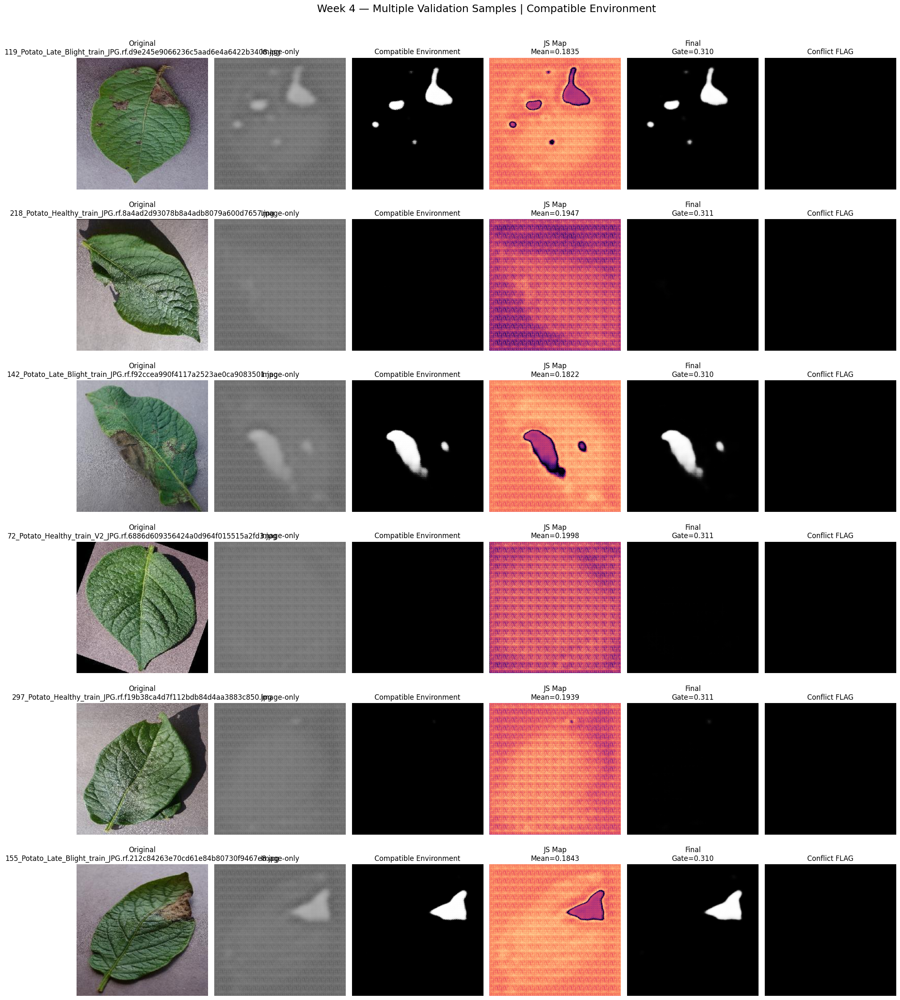

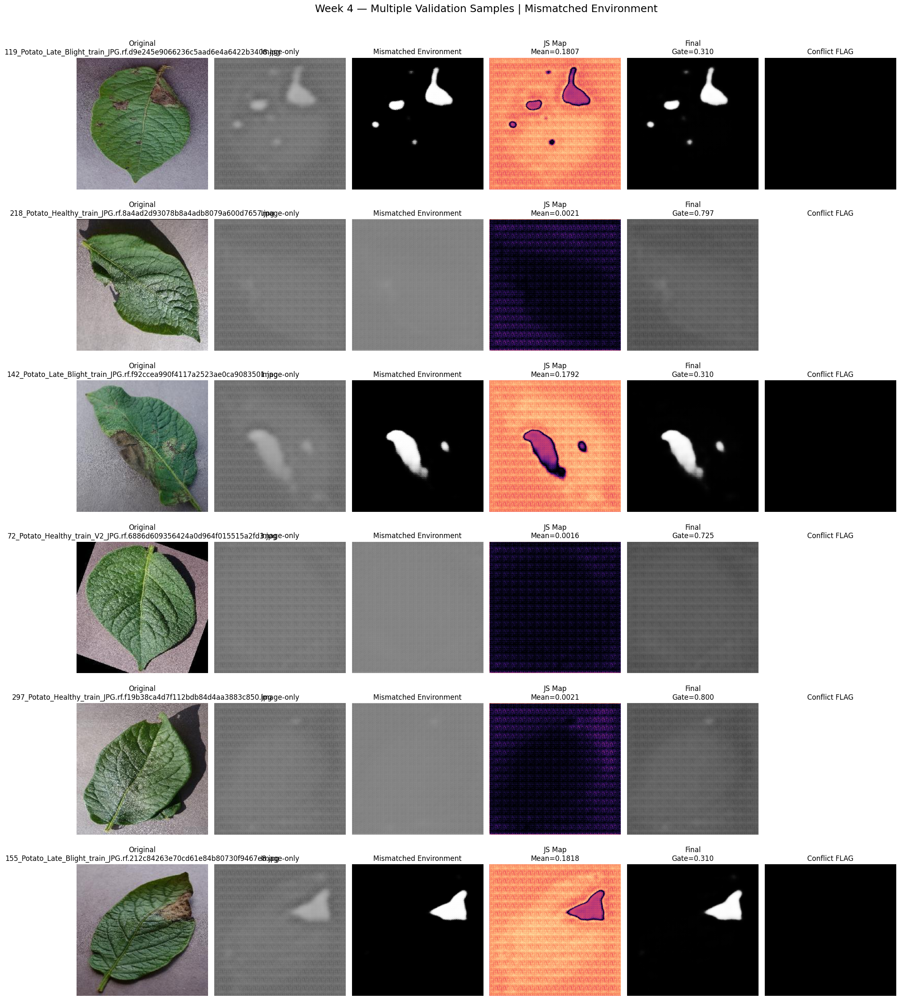


VISUALIZATION SUMMARY

[1] Validation index: 6
Image: 119_Potato_Late_Blight_train_JPG.rf.d9e245e9066236c5aad6e4a6422b3408.jpg
Mismatched environment from: 309_Potato_Healthy_train_JPG.rf.45e297e1c10064cc224be1e06fc088b8.jpg
Compatible JS: 0.183503
Mismatched JS: 0.180666
Compatible gate: 0.30957
Mismatched gate: 0.30957
Compatible conflict: False
Mismatched conflict: False

[2] Validation index: 34
Image: 218_Potato_Healthy_train_JPG.rf.8a4ad2d93078b8a4adb8079a600d7657.jpg
Mismatched environment from: 197_Potato_Late_Blight_train_JPG.rf.3fe7583ff6a7720bbb4d41a64bd590e5.jpg
Compatible JS: 0.194725
Mismatched JS: 0.002091
Compatible gate: 0.310547
Mismatched gate: 0.796875
Compatible conflict: False
Mismatched conflict: True

[3] Validation index: 11
Image: 142_Potato_Late_Blight_train_JPG.rf.f92ccea990f4117a2523ae0ca9083501.jpg
Mismatched environment from: 309_Potato_Healthy_train_JPG.rf.45e297e1c10064cc224be1e06fc088b8.jpg
Compatible JS: 0.182181
Mismatched JS: 0.179178
Compatible ga

In [ ]:
# =====================================================================
# WEEK 4 — VISUALIZE MULTIPLE VALIDATION IMAGES AT ONCE
# Shows for each sample:
#   Original
#   Image-only prediction
#   Environment-conditioned prediction
#   JS disagreement map
#   Final prediction
#   Conflict flag
#
# Compatible + intentionally mismatched environment are both shown.
# =====================================================================

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import torch

# -------------------------------------------------------------
# SETTINGS
# -------------------------------------------------------------

# Number of images to visualize
NUM_IMAGES = 6

# Set this if you want specific validation indices.
# Example:
# CUSTOM_INDICES = [0, 5, 12, 25, 50, 80]
#
# Use None for random selection.
CUSTOM_INDICES = None

# Random seed for reproducible random selection
VIS_SEED = 123

# Save directory
VIS_DIR = os.path.join(
    OUTPUT_DIR,
    "multi_image_visualizations"
)

os.makedirs(
    VIS_DIR,
    exist_ok=True
)


# -------------------------------------------------------------
# SELECT INDICES
# -------------------------------------------------------------

if CUSTOM_INDICES is not None:

    indices = CUSTOM_INDICES

else:

    rng = random.Random(
        VIS_SEED
    )

    total_samples = len(
        valid_ds
    )

    NUM_IMAGES = min(
        NUM_IMAGES,
        total_samples
    )

    indices = rng.sample(
        range(total_samples),
        NUM_IMAGES
    )


print("=" * 80)
print("SELECTED VALIDATION IMAGES")
print("=" * 80)

print(
    "Indices:",
    indices
)


# -------------------------------------------------------------
# HELPER: RUN ONE SAMPLE
# -------------------------------------------------------------

@torch.no_grad()
def get_visual_outputs(
    model,
    dataset,
    index
):

    model.eval()

    sample = dataset[
        index
    ]

    image = sample[
        "image"
    ].unsqueeze(
        0
    ).to(
        DEVICE
    )

    env_c = sample[
        "environment_compatible"
    ].unsqueeze(
        0
    ).to(
        DEVICE
    )

    env_m = sample[
        "environment_mismatch"
    ].unsqueeze(
        0
    ).to(
        DEVICE
    )

    # ---------------------------------------------------------
    # Forward
    # ---------------------------------------------------------

    with torch.autocast(
        device_type="cuda",
        dtype=torch.float16,
        enabled=AMP
    ):

        z = model.encode_image(
            image
        )

        image_feat = (
            model.image_features(
                z
            )
        )

        # Compatible environment
        out_c = model.predict_from_features(
            z,
            image_feat,
            env_c
        )

        # Mismatched environment
        out_m = model.predict_from_features(
            z,
            image_feat,
            env_m
        )

    # ---------------------------------------------------------
    # Convert image back to display format
    # ---------------------------------------------------------

    display = (
        image[0]
        .detach()
        .cpu()
        .permute(
            1,
            2,
            0
        )
        .numpy()
    )

    mean = np.array(
        [
            0.485,
            0.456,
            0.406
        ]
    )

    std = np.array(
        [
            0.229,
            0.224,
            0.225
        ]
    )

    display = (
        display * std + mean
    )

    display = np.clip(
        display,
        0,
        1
    )

    # ---------------------------------------------------------
    # Image-only prediction
    # ---------------------------------------------------------

    image_pred = torch.sigmoid(
        out_c[
            "image_logits"
        ].float()
    )[0, 0].cpu().numpy()

    # ---------------------------------------------------------
    # Compatible environment prediction
    # ---------------------------------------------------------

    env_pred_c = torch.sigmoid(
        out_c[
            "environment_logits"
        ].float()
    )[0, 0].cpu().numpy()

    # ---------------------------------------------------------
    # Mismatched environment prediction
    # ---------------------------------------------------------

    env_pred_m = torch.sigmoid(
        out_m[
            "environment_logits"
        ].float()
    )[0, 0].cpu().numpy()

    # ---------------------------------------------------------
    # JS disagreement maps
    # ---------------------------------------------------------

    js_c = out_c[
        "js_map"
    ][0, 0].cpu().numpy()

    js_m = out_m[
        "js_map"
    ][0, 0].cpu().numpy()

    # ---------------------------------------------------------
    # Gate values
    # ---------------------------------------------------------

    gate_c = float(
        out_c[
            "learned_gate"
        ].item()
    )

    gate_m = float(
        out_m[
            "learned_gate"
        ].item()
    )

    # ---------------------------------------------------------
    # Final compatible prediction
    #
    # Low conflict  -> fused
    # High conflict -> image-only
    # ---------------------------------------------------------

    gate_c_tensor = torch.tensor(
        gate_c,
        dtype=torch.float32,
        device=DEVICE
    ).view(
        1,
        1,
        1,
        1
    )

    final_c_logits = (
        (
            1.0
            -
            gate_c_tensor
        )
        *
        out_c[
            "fused_logits"
        ].float()
        +
        gate_c_tensor
        *
        out_c[
            "image_logits"
        ].float()
    )

    final_c = torch.sigmoid(
        final_c_logits
    )[0, 0].cpu().numpy()

    # ---------------------------------------------------------
    # Final mismatched prediction
    # ---------------------------------------------------------

    gate_m_tensor = torch.tensor(
        gate_m,
        dtype=torch.float32,
        device=DEVICE
    ).view(
        1,
        1,
        1,
        1
    )

    final_m_logits = (
        (
            1.0
            -
            gate_m_tensor
        )
        *
        out_m[
            "fused_logits"
        ].float()
        +
        gate_m_tensor
        *
        out_m[
            "image_logits"
        ].float()
    )

    final_m = torch.sigmoid(
        final_m_logits
    )[0, 0].cpu().numpy()

    # ---------------------------------------------------------
    # Conflict flags
    # ---------------------------------------------------------

    conflict_c = gate_c >= 0.5
    conflict_m = gate_m >= 0.5

    return {
        "sample": sample,
        "display": display,

        "image_pred": image_pred,

        "env_pred_c": env_pred_c,
        "env_pred_m": env_pred_m,

        "js_c": js_c,
        "js_m": js_m,

        "final_c": final_c,
        "final_m": final_m,

        "gate_c": gate_c,
        "gate_m": gate_m,

        "conflict_c": conflict_c,
        "conflict_m": conflict_m
    }


# -------------------------------------------------------------
# GENERATE ALL VISUAL OUTPUTS
# -------------------------------------------------------------

results = []

for index in indices:

    print(
        f"Processing validation index {index}..."
    )

    result = get_visual_outputs(
        model,
        valid_ds,
        index
    )

    results.append(
        result
    )


# -------------------------------------------------------------
# FIGURE 1:
# Compatible environments
#
# Each row = one image
# Columns:
# Original | Image-only | Env-conditioned |
# JS map | Final | Conflict flag
# -------------------------------------------------------------

fig, axes = plt.subplots(
    len(results),
    6,
    figsize=(
        20,
        4 * len(results)
    )
)

# Handle single-image case
if len(results) == 1:
    axes = np.expand_dims(
        axes,
        axis=0
    )


for row_idx, result in enumerate(
    results
):

    display = result[
        "display"
    ]

    image_pred = result[
        "image_pred"
    ]

    env_pred_c = result[
        "env_pred_c"
    ]

    js_c = result[
        "js_c"
    ]

    final_c = result[
        "final_c"
    ]

    gate_c = result[
        "gate_c"
    ]

    conflict_c = result[
        "conflict_c"
    ]

    filename = result[
        "sample"
    ]["filename"]

    # ---------------------------------------------------------
    # Column 1 — Original
    # ---------------------------------------------------------

    axes[
        row_idx,
        0
    ].imshow(
        display
    )

    axes[
        row_idx,
        0
    ].set_title(
        f"Original\n{filename}"
    )

    # ---------------------------------------------------------
    # Column 2 — Image-only
    # ---------------------------------------------------------

    axes[
        row_idx,
        1
    ].imshow(
        image_pred,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[
        row_idx,
        1
    ].set_title(
        "Image-only"
    )

    # ---------------------------------------------------------
    # Column 3 — Environment-conditioned
    # ---------------------------------------------------------

    axes[
        row_idx,
        2
    ].imshow(
        env_pred_c,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[
        row_idx,
        2
    ].set_title(
        "Compatible Environment"
    )

    # ---------------------------------------------------------
    # Column 4 — JS disagreement
    # ---------------------------------------------------------

    im = axes[
        row_idx,
        3
    ].imshow(
        js_c,
        cmap="magma"
    )

    axes[
        row_idx,
        3
    ].set_title(
        f"JS Map\nMean={js_c.mean():.4f}"
    )

    # ---------------------------------------------------------
    # Column 5 — Final
    # ---------------------------------------------------------

    axes[
        row_idx,
        4
    ].imshow(
        final_c,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[
        row_idx,
        4
    ].set_title(
        f"Final\nGate={gate_c:.3f}"
    )

    # ---------------------------------------------------------
    # Column 6 — Conflict flag
    # ---------------------------------------------------------

    axes[
        row_idx,
        5
    ].imshow(
        np.ones_like(
            js_c
        )
        *
        conflict_c,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[
        row_idx,
        5
    ].set_title(
        "Conflict FLAG"
    )

    for col in range(6):

        axes[
            row_idx,
            col
        ].axis("off")


fig.suptitle(
    "Week 4 — Multiple Validation Samples | Compatible Environment",
    fontsize=18,
    y=1.01
)

plt.tight_layout()

compatible_path = os.path.join(
    VIS_DIR,
    "multiple_validation_compatible.png"
)

plt.savefig(
    compatible_path,
    dpi=180,
    bbox_inches="tight"
)

plt.show()


# -------------------------------------------------------------
# FIGURE 2:
# INTENTIONALLY MISMATCHED ENVIRONMENT
#
# Same images, different environment sequence
# -------------------------------------------------------------

fig, axes = plt.subplots(
    len(results),
    6,
    figsize=(
        20,
        4 * len(results)
    )
)

if len(results) == 1:
    axes = np.expand_dims(
        axes,
        axis=0
    )


for row_idx, result in enumerate(
    results
):

    display = result[
        "display"
    ]

    image_pred = result[
        "image_pred"
    ]

    env_pred_m = result[
        "env_pred_m"
    ]

    js_m = result[
        "js_m"
    ]

    final_m = result[
        "final_m"
    ]

    gate_m = result[
        "gate_m"
    ]

    conflict_m = result[
        "conflict_m"
    ]

    filename = result[
        "sample"
    ]["filename"]

    mismatch_filename = result[
        "sample"
    ]["mismatch_filename"]

    # ---------------------------------------------------------
    # Original
    # ---------------------------------------------------------

    axes[
        row_idx,
        0
    ].imshow(
        display
    )

    axes[
        row_idx,
        0
    ].set_title(
        f"Original\n{filename}"
    )

    # ---------------------------------------------------------
    # Image-only
    # ---------------------------------------------------------

    axes[
        row_idx,
        1
    ].imshow(
        image_pred,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[
        row_idx,
        1
    ].set_title(
        "Image-only"
    )

    # ---------------------------------------------------------
    # Mismatched environment prediction
    # ---------------------------------------------------------

    axes[
        row_idx,
        2
    ].imshow(
        env_pred_m,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[
        row_idx,
        2
    ].set_title(
        "Mismatched Environment"
    )

    # ---------------------------------------------------------
    # JS disagreement
    # ---------------------------------------------------------

    axes[
        row_idx,
        3
    ].imshow(
        js_m,
        cmap="magma"
    )

    axes[
        row_idx,
        3
    ].set_title(
        f"JS Map\nMean={js_m.mean():.4f}"
    )

    # ---------------------------------------------------------
    # Final
    # ---------------------------------------------------------

    axes[
        row_idx,
        4
    ].imshow(
        final_m,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[
        row_idx,
        4
    ].set_title(
        f"Final\nGate={gate_m:.3f}"
    )

    # ---------------------------------------------------------
    # Conflict flag
    # ---------------------------------------------------------

    axes[
        row_idx,
        5
    ].imshow(
        np.ones_like(
            js_m
        )
        *
        conflict_m,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[
        row_idx,
        5
    ].set_title(
        "Conflict FLAG"
    )

    for col in range(6):

        axes[
            row_idx,
            col
        ].axis("off")


fig.suptitle(
    "Week 4 — Multiple Validation Samples | Mismatched Environment",
    fontsize=18,
    y=1.01
)

plt.tight_layout()

mismatch_path = os.path.join(
    VIS_DIR,
    "multiple_validation_mismatched.png"
)

plt.savefig(
    mismatch_path,
    dpi=180,
    bbox_inches="tight"
)

plt.show()


# -------------------------------------------------------------
# NUMERIC SUMMARY
# -------------------------------------------------------------

print("\n" + "=" * 80)
print("VISUALIZATION SUMMARY")
print("=" * 80)

for i, result in enumerate(
    results
):

    sample = result[
        "sample"
    ]

    print(
        f"\n[{i+1}] Validation index: {indices[i]}"
    )

    print(
        "Image:",
        sample["filename"]
    )

    print(
        "Mismatched environment from:",
        sample["mismatch_filename"]
    )

    print(
        "Compatible JS:",
        round(
            result["js_c"].mean(),
            6
        )
    )

    print(
        "Mismatched JS:",
        round(
            result["js_m"].mean(),
            6
        )
    )

    print(
        "Compatible gate:",
        round(
            result["gate_c"],
            6
        )
    )

    print(
        "Mismatched gate:",
        round(
            result["gate_m"],
            6
        )
    )

    print(
        "Compatible conflict:",
        result["conflict_c"]
    )

    print(
        "Mismatched conflict:",
        result["conflict_m"]
    )


print("\nSaved files:")
print(
    compatible_path
)

print(
    mismatch_path
)